# Sweep Analytics — Latent JacobianODE

Post-training diagnostics and model selection for a JacobianODE hyperparameter sweep.

**Inputs:** W&B project (and optional group) containing completed sweep runs.

**Workflow:**
1. Collect W&B runs and apply physics-informed model selection (C1/C2/C3)
2. Visualize selection criteria
3. Load the best model
4. Run diagnostics: reconstruction quality, prediction quality, Lyapunov exponents,
   latent space analysis, smoothness, Jacobian diagnostics, FNN loss, and more.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf
import os
import pandas as pd
import torch
from torch.autograd.functional import jacobian as autograd_jacobian
from torch.utils.data import RandomSampler, DataLoader
from tqdm.auto import tqdm
import wandb

from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    seed_everything,
    make_trajectories,
    postprocess_data,
    create_dataloaders,
    load_run,
    load_checkpoint,
    select_best_model,
    DiagnosticMetrics,
)
from JacobianODE.jacobians.metrics import r2_score, normalized_mse as nmse_fn, mase
from JacobianODE.jacobians.tuning import select_from_wandb_runs
from JacobianODE.jacobians.lightning_base import loop_closure
from JacobianODE.models.latent_jacobian import LitLatentJacobianODE
from JacobianODE.fnn import loss_false, loss_amplification

torch.set_float32_matmul_precision('high')

## 1. Settings

Specify the W&B project, optional group, and save directory for checkpoints.

In [3]:
# ================================================================
# W&B project and group (EDIT THESE)
# ================================================================
WANDB_ENTITY  = "JacobianODE"
# WANDB_PROJECT = "Lorenz_IND012_N1_D1_NormTrue_L3__JacobianODE"  # <-- CHANGE THIS
# WANDB_GROUP   = "MLP_lc_sweep_enc_warmup_5"  # Set to a string to filter by group, or None for all runs

# WANDB_PROJECT = "Lorenz_IND012_N1_D1_NormTrue_L6__JacobianODE"
# WANDB_GROUP   = "sweep_from_scratch_lc_only_enc_warmup_5"
# WANDB_GROUP   = "sweep_from_scratch_lc_only_fnn1e-5_enc_warmup_5"

WANDB_PROJECT = "Lorenz_IND0_N25_D1_NormTrue_L3__JacobianODE"
WANDB_GROUP   = "sweep_from_scratch_lc_only_fnn0_enc_warmup_5"

WANDB_PROJECT_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

# ================================================================
# Checkpoint save directory
# ================================================================
SAVE_DIR = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs"

# ================================================================
# Known true Lyapunov exponents (for Lorenz: sigma=10, rho=28, beta=8/3)
# ================================================================
TRUE_LYAPUNOV = [0.91, 0.0, -14.57]

print(f"W&B project: {WANDB_PROJECT_PATH}")
print(f"W&B group:   {WANDB_GROUP}")
print(f"Save dir:    {SAVE_DIR}")

W&B project: JacobianODE/Lorenz_IND0_N25_D1_NormTrue_L3__JacobianODE
W&B group:   sweep_from_scratch_lc_only_fnn0_enc_warmup_5
Save dir:    /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs


## 2. Collect W&B Runs

In [4]:
api = wandb.Api()
try:
    run_filters = {"group": WANDB_GROUP} if WANDB_GROUP else None
    all_runs = api.runs(WANDB_PROJECT_PATH, filters=run_filters)
    msg = f"Found {len(all_runs)} total runs in {WANDB_PROJECT_PATH}"
    if WANDB_GROUP:
        msg += f" (group={WANDB_GROUP})"
    print(msg)
except Exception as e:
    print(f"Could not query project: {e}")
    all_runs = []

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/eisenaj/.netrc.


Found 9 total runs in JacobianODE/Lorenz_IND0_N25_D1_NormTrue_L3__JacobianODE (group=sweep_from_scratch_lc_only_fnn0_enc_warmup_5)


In [5]:
def _is_jac_ode_run(run):
    """Return True if this run has an encoder (i.e. is a JacobianODE run)."""
    return 'model' in run.config and 'encoder' in run.config.get('model', {})


def _get_loop_closure_weight(run):
    """Robustly extract loop_closure_weight from W&B run config (handles nested and flat formats)."""
    # Nested: config["training"]["lightning"]["loop_closure_weight"]
    try:
        val = run.config.get('training', {}).get('lightning', {}).get('loop_closure_weight')
        if val is not None:
            return float(val)
    except (TypeError, AttributeError):
        pass
    # Flat keys (W&B may use different separators)
    for key in ("training.lightning.loop_closure_weight", "training/lightning/loop_closure_weight"):
        if hasattr(run.config, 'get') and key in run.config:
            return float(run.config[key])
    return None


# Set to True to delete crashed runs from W&B (default False — keeps them for debugging, e.g. lc=0)
DELETE_CRASHED_RUNS = False

# Diagnostic: list all runs (helps debug why lc=0 may not show — e.g. crashed runs were being deleted)
print("All runs (state, loop_closure_weight):")
for r in all_runs:
    lc = _get_loop_closure_weight(r)
    lc_str = str(lc) if lc is not None else "?"
    print(f"  {r.id}: state={r.state}, lc={lc_str}")
print()

crashed_ids = []
for run in all_runs:
    if run.state in ('crashed', 'failed') and _is_jac_ode_run(run):
        lam = _get_loop_closure_weight(run)
        if DELETE_CRASHED_RUNS:
            print(f"CRASHED: run_id={run.id} (loop_closure_weight={lam}) — deleting from W&B")
            run.delete()
            crashed_ids.append(run.id)
        else:
            print(f"CRASHED: run_id={run.id} (loop_closure_weight={lam}) — keeping for debugging (set DELETE_CRASHED_RUNS=True to delete)")

if crashed_ids:
    print(f"\nDeleted {len(crashed_ids)} crashed run(s). Re-query if needed.")
elif any(r.state in ('crashed', 'failed') and _is_jac_ode_run(r) for r in all_runs):
    print("\nCrashed runs kept (DELETE_CRASHED_RUNS=False). Check run logs for debugging.")
else:
    print("No crashed JacobianODE runs found.")

All runs (state, loop_closure_weight):
  pntmk0cq: state=finished, lc=1e-06
  r8883sy8: state=finished, lc=0.001
  rzp2xson: state=finished, lc=0.0001
  d7mekfis: state=finished, lc=0.0
  48xop1jb: state=finished, lc=1e-05
  n8nh0mg9: state=finished, lc=0.01
  11x5yxzd: state=finished, lc=0.1
  mi6po4ku: state=finished, lc=10.0
  4hgt7oxy: state=finished, lc=1.0

No crashed JacobianODE runs found.


In [6]:
# ----------------------------------------------------------------
# Build sorted list of finished sweep runs
# ----------------------------------------------------------------
sweep_run_ids = []
sweep_lambdas = []

for run in all_runs:
    if run.state != 'finished' or not _is_jac_ode_run(run):
        continue
    if run.id in crashed_ids:
        continue
    lc_weight = _get_loop_closure_weight(run)
    if lc_weight is not None:
        sweep_run_ids.append(run.id)
        sweep_lambdas.append(lc_weight)

# Sort by lambda value
sorted_pairs = sorted(zip(sweep_lambdas, sweep_run_ids))
sweep_lambdas = [p[0] for p in sorted_pairs]
sweep_run_ids = [p[1] for p in sorted_pairs]

print(f"\nFound {len(sweep_run_ids)} finished sweep runs:")
for lam, rid in zip(sweep_lambdas, sweep_run_ids):
    print(f"  loop_closure_weight={lam} -> run_id={rid}")


Found 9 finished sweep runs:
  loop_closure_weight=0.0 -> run_id=d7mekfis
  loop_closure_weight=1e-06 -> run_id=pntmk0cq
  loop_closure_weight=1e-05 -> run_id=48xop1jb
  loop_closure_weight=0.0001 -> run_id=rzp2xson
  loop_closure_weight=0.001 -> run_id=r8883sy8
  loop_closure_weight=0.01 -> run_id=n8nh0mg9
  loop_closure_weight=0.1 -> run_id=11x5yxzd
  loop_closure_weight=1.0 -> run_id=4hgt7oxy
  loop_closure_weight=10.0 -> run_id=mi6po4ku


## 3. Compute Diagnostics and Select Best Model

Uses the tuning module's `select_from_wandb_runs` for physics-informed selection:

- **C1 (one-step MASE)**: model must beat persistence baseline (MASE < 1)
- **C2 (loop closure)**: loop closure loss must be below `sqrt(n_dims)`
- **C3 (eigenvalue)**: fraction of fast eigenvalues must be below threshold

In [7]:
# Load one run to determine data dimensionality
_run0, _cfg0, _eq0, _dt0, _values0, _, _, _, _, _ = load_run(
    WANDB_PROJECT_PATH,
    run_id=sweep_run_ids[0],
    save_dir=SAVE_DIR,
    generate_data=True,
    verbose=False,
)
n_dims = _values0.shape[-1]
dt = _dt0
print(f"n_dims = {n_dims}, dt = {dt:.4f}")
print(f"sqrt(n_dims) = {np.sqrt(n_dims):.4f}")

n_dims = 3, dt = 0.0150
sqrt(n_dims) = 1.7321


In [ ]:
sweep_result = select_from_wandb_runs(
    run_ids=sweep_run_ids,
    project=WANDB_PROJECT_PATH,
    dt=dt,
    n_dims=n_dims,
    n_batches=100,
    eigenvalue_threshold=0.001,
    use_loop_closure=True,
    lambda_values=sweep_lambdas,
    save_dir=SAVE_DIR,
    verbose=True,
)

result = sweep_result.selection
all_diagnostics = sweep_result.diagnostics

print("\n" + "=" * 60)
print("MODEL SELECTION RESULT")
print("=" * 60)
print(f"Best lambda:    {sweep_lambdas[result.best_index]}")
print(f"Best run ID:    {sweep_run_ids[result.best_index]}")
print(f"Best traj loss: {result.best_metrics.trajectory_val_loss:.6f}")
print(f"\nCriteria applied: {result.criteria_applied}")
print(f"Surviving models: {len(result.surviving_indices)} / {len(all_diagnostics)}")

Loading run d7mekfis (1/9)
Loading checkpoint epoch=9-step=2000.ckpt...
  Computing diagnostics (100 batches)...


  0%|          | 0/100 [00:00<?, ?it/s]

  Cached to /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs/diagnostics_cache/d7mekfis_n100.json
  run=d7mekfis: DiagnosticMetrics(one_step_mase=0.5657454858046301, loop_closure_loss=81.2733620262146, fast_eigenvalue_fraction=0.0012662037037037036, trajectory_val_loss=0.020381219489499926)
Loading run pntmk0cq (2/9)
Loading checkpoint epoch=23-step=4800.ckpt...
  Computing diagnostics (100 batches)...


  0%|          | 0/100 [00:00<?, ?it/s]

  Cached to /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs/diagnostics_cache/pntmk0cq_n100.json
  run=pntmk0cq: DiagnosticMetrics(one_step_mase=0.43703689883368235, loop_closure_loss=4.311165217161179, fast_eigenvalue_fraction=0.0, trajectory_val_loss=0.005637766811996698)
Loading run 48xop1jb (3/9)
Loading checkpoint epoch=23-step=4800.ckpt...
  Computing diagnostics (100 batches)...


  0%|          | 0/100 [00:00<?, ?it/s]

## 4. Visualize Selection

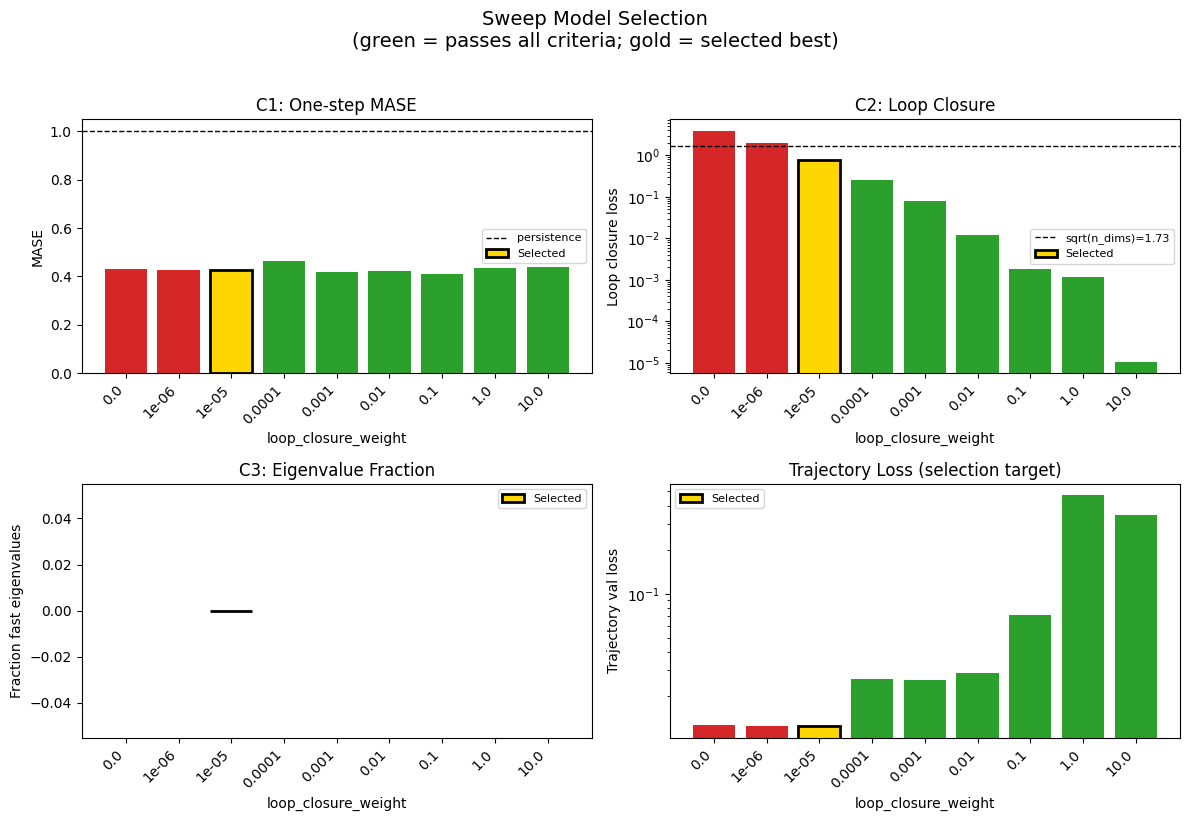

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

one_step_mases = [m.one_step_mase for m in all_diagnostics]
loop_closure_losses = [m.loop_closure_loss for m in all_diagnostics]
eig_fracs = [m.fast_eigenvalue_fraction for m in all_diagnostics]
traj_losses = [m.trajectory_val_loss for m in all_diagnostics]

colors = ['tab:green' if i in result.surviving_indices else 'tab:red'
          for i in range(len(all_diagnostics))]
x_labels = [str(v) for v in sweep_lambdas]
x_pos = range(len(sweep_lambdas))

# Panel 1: One-step MASE
axes[0, 0].bar(x_pos, one_step_mases, color=colors)
if result.best_index is not None:
    axes[0, 0].bar(result.best_index, one_step_mases[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[0, 0].axhline(y=1.0, color='k', linestyle='--', lw=1, label='persistence')
axes[0, 0].set_xticks(x_pos); axes[0, 0].set_xticklabels(x_labels, rotation=45, ha='right')
axes[0, 0].set_ylabel('MASE'); axes[0, 0].set_title('C1: One-step MASE')
axes[0, 0].legend(fontsize=8)

# Panel 2: Loop closure loss
axes[0, 1].bar(x_pos, loop_closure_losses, color=colors)
if result.best_index is not None:
    axes[0, 1].bar(result.best_index, loop_closure_losses[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[0, 1].axhline(y=np.sqrt(n_dims), color='k', linestyle='--', lw=1,
                   label=f'sqrt(n_dims)={np.sqrt(n_dims):.2f}')
axes[0, 1].set_xticks(x_pos); axes[0, 1].set_xticklabels(x_labels, rotation=45, ha='right')
axes[0, 1].set_ylabel('Loop closure loss'); axes[0, 1].set_title('C2: Loop Closure')
axes[0, 1].legend(fontsize=8); axes[0, 1].set_yscale('log')

# Panel 3: Fast eigenvalue fraction
axes[1, 0].bar(x_pos, eig_fracs, color=colors)
if result.best_index is not None:
    axes[1, 0].bar(result.best_index, eig_fracs[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[1, 0].set_xticks(x_pos); axes[1, 0].set_xticklabels(x_labels, rotation=45, ha='right')
axes[1, 0].set_ylabel('Fraction fast eigenvalues'); axes[1, 0].set_title('C3: Eigenvalue Fraction')
axes[1, 0].legend(fontsize=8)

# Panel 4: Trajectory val loss (selection target)
axes[1, 1].bar(x_pos, traj_losses, color=colors)
if result.best_index is not None:
    axes[1, 1].bar(result.best_index, traj_losses[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[1, 1].set_xticks(x_pos); axes[1, 1].set_xticklabels(x_labels, rotation=45, ha='right')
axes[1, 1].set_ylabel('Trajectory val loss'); axes[1, 1].set_title('Trajectory Loss (selection target)')
axes[1, 1].legend(fontsize=8); axes[1, 1].set_yscale('log')

for ax in axes.flat:
    ax.set_xlabel('loop_closure_weight')

fig.suptitle(
    'Sweep Model Selection\n'
    '(green = passes all criteria; gold = selected best)',
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()

## 5. Load the Best Model

Load the selected model's architecture, data, and checkpoint from W&B.

In [11]:
idx = result.best_index
# idx = 0  # Override to manually select a different model

best_run_id = sweep_run_ids[idx]
best_lambda = sweep_lambdas[idx]
print(f"Loading model: run_id={best_run_id}, loop_closure_weight={best_lambda}")

# Step 1: Load architecture + trajectory data
run, best_cfg, eq, dt, values, _, _, _, _, best_lit_model = load_run(
    WANDB_PROJECT_PATH,
    run_id=best_run_id,
    save_dir=SAVE_DIR,
    generate_data=True,
    verbose=True,
)

# Step 2: Build dataloaders
train_dl, val_dl, test_dl, trajs = create_dataloaders(
    best_cfg, values, verbose=True, return_full_obs=True
)
test_trajs_full = trajs['test_trajs_full'].sequence

# Step 3: Load checkpoint
load_checkpoint(run, best_cfg, best_lit_model, save_dir=SAVE_DIR, verbose=True)

# Step 4: Restore attributes
best_lit_model.true_lyapunov_exponents = torch.tensor(TRUE_LYAPUNOV, dtype=torch.float32)
best_lit_model.eval()

# Extract useful config values
mu = best_cfg.data.postprocessing.mu
sigma = best_cfg.data.postprocessing.sigma
OBSERVED_INDICES = best_cfg.data.train_test_params.delay_embedding_params.observed_indices
N_DELAYS = best_cfg.data.train_test_params.delay_embedding_params.n_delays
DELAY_SPACING = best_cfg.data.train_test_params.delay_embedding_params.delay_spacing
PREDICTION_STEPS = best_lit_model.prediction_steps
n_dims = values.shape[-1]
n_obs = trajs['train_trajs'].sequence.shape[-1]

print(f"\nModel type: {type(best_lit_model).__name__}")
print(f"Total params: {sum(p.numel() for p in best_lit_model.parameters()):,}")
print(f"Test trajectories (full obs): {test_trajs_full.shape}")

Loading model: run_id=4w6f58h4, loop_closure_weight=1e-05


Sequence Indices:   0%|          | 0/1155 [00:00<?, ?it/s]

Train dataset shape: torch.Size([25410, 45, 3])
Validation dataset shape: torch.Size([8085, 45, 3])
Test dataset shape: torch.Size([3465, 45, 3])
Train trajectories dataset shape: torch.Size([22, 1200, 3])
Validation trajectories dataset shape: torch.Size([7, 1200, 3])
Test trajectories dataset shape: torch.Size([3, 1200, 3])
Loading checkpoint epoch=18-step=3800.ckpt...

Model type: LitLatentJacobianODE
Total params: 6,786,221
Test trajectories (full obs): torch.Size([3, 1200, 3])


## 6. Reconstruction Quality

Encode-then-decode (no prediction) to check autoencoder quality.

Reconstruction nMSE: 0.000379


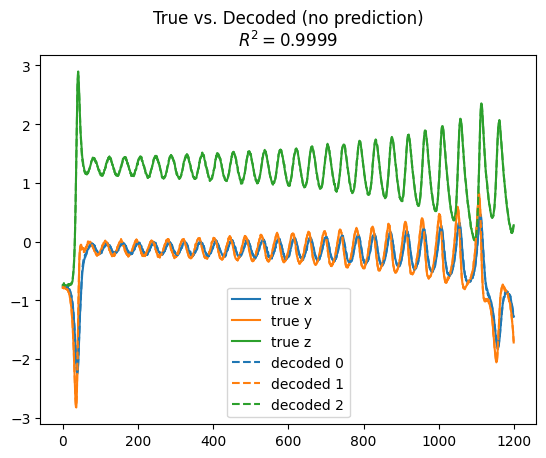

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lit_model = best_lit_model.to(device)
lit_model.eval()

# Reconstruction on test data
with torch.no_grad():
    batch = test_dl.dataset.sequence[:16].to(device)
    z = lit_model.encode_trajectory(batch)
    recon = lit_model.decode_trajectory(z)
    margin = getattr(lit_model.encoder, 'context_margin', 0)
    targets = batch[:, margin:] if margin > 0 else batch
    recon_mse = ((recon - targets)**2).mean().item()
    recon_nmse = recon_mse / targets.var().item()
    print(f"Reconstruction nMSE: {recon_nmse:.6f}")

# Plot: true vs decoded (first test trajectory)
test_trajs_obs = trajs['test_trajs'].sequence
with torch.no_grad():
    latent_traj_full = lit_model.encode_trajectory(test_trajs_obs.to(device))
    traj_decoded_full = lit_model.decode_trajectory(latent_traj_full)

latent_traj_full = latent_traj_full.cpu()
traj_decoded_full = traj_decoded_full.cpu()

dim_names = ['x', 'y', 'z']
for i in range(min(3, test_trajs_full.shape[-1])):
    plt.plot(test_trajs_full[0, :, i].numpy(), c=f"C{i}", label=f'true {dim_names[i]}')
for i in range(traj_decoded_full.shape[-1]):
    plt.plot(traj_decoded_full[0, :, i].numpy(), c=f"C{i}", linestyle='--', label=f'decoded {i}')
r2_val = r2_score(
    test_trajs_obs.reshape(-1, test_trajs_obs.shape[-1]),
    traj_decoded_full.reshape(-1, traj_decoded_full.shape[-1]),
)
plt.title(f"True vs. Decoded (no prediction)\n$R^2 = {r2_val:.4f}$")
plt.legend()
plt.show()

## 7. Prediction Quality

Teacher-forced (one-step) and free-running predictions on validation data.

In [20]:
model_maes_forced = []
model_maes_free = []
persistence_maes = []

n_batches = 10
RAND_SEED = 42
generator = torch.Generator().manual_seed(RAND_SEED)
dl = val_dl
num_samples = n_batches * dl.batch_size
rand_sampler = RandomSampler(dl.dataset, num_samples=num_samples, replacement=False, generator=generator)
rand_dl = DataLoader(
    dl.dataset, batch_size=dl.batch_size, sampler=rand_sampler,
    num_workers=dl.num_workers, pin_memory=getattr(dl, 'pin_memory', False),
)

for i, batch in enumerate(tqdm(rand_dl, desc="Evaluating", total=n_batches)):
    if i >= n_batches:
        break
    batch = batch.to(device)
    with torch.no_grad():
        ret_forced = lit_model.trajectory_model_step(batch, alpha_teacher_forcing=1, return_decoded=True)
        ret_free = lit_model.trajectory_model_step(batch, alpha_teacher_forcing=0, return_decoded=True)
    model_maes_forced.append(ret_forced['metric_vals']['model_mae'].item())
    model_maes_free.append(ret_free['metric_vals']['model_mae'].item())
    persistence_maes.append(ret_free['metric_vals']['persistence_mae'].item())

forced_mase = torch.tensor(model_maes_forced).mean() / torch.tensor(persistence_maes).mean()
free_mase = torch.tensor(model_maes_free).mean() / torch.tensor(persistence_maes).mean()

print(f"Teacher-forced MASE: {forced_mase:.4f}")
print(f"Free-running MASE:   {free_mase:.4f}")
print(f"Mean persistence MAE: {torch.tensor(persistence_maes).mean():.6f}")

Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Teacher-forced MASE: 0.4367
Free-running MASE:   0.8218
Mean persistence MAE: 0.033334


## 8. Estimated Dimension and Participation Ratio

/home/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


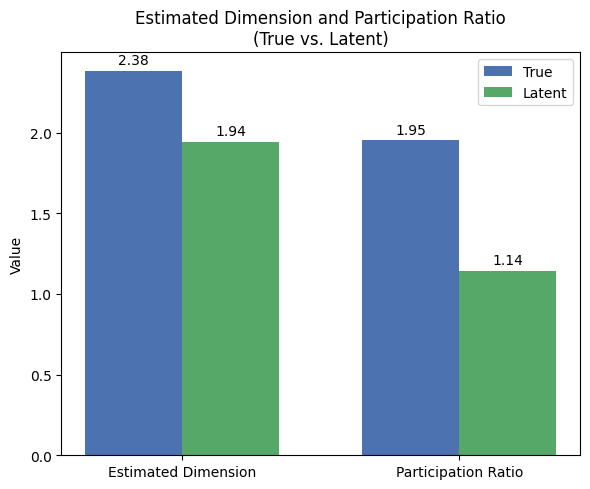

In [22]:
true_vars = test_trajs_full.reshape(-1, test_trajs_full.shape[-1]).var(axis=0)
est_dim_true = (true_vars / true_vars.max()).sum()
latent_vars = latent_traj_full.reshape(-1, latent_traj_full.shape[-1]).var(axis=0)
est_dim_latent = (latent_vars / latent_vars.max()).sum()

def participation_ratio(X):
    X_flat = X.reshape(-1, X.shape[-1])
    cov = np.cov(X_flat, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    return (eigvals.sum())**2 / ((eigvals**2).sum() + 1e-12)

pr_true = participation_ratio(test_trajs_full)
pr_latent = participation_ratio(latent_traj_full)

labels = ['Estimated Dimension', 'Participation Ratio']
true_values = [est_dim_true.item(), pr_true]
latent_values = [est_dim_latent.item(), pr_latent]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 5))
bars1 = ax.bar(x - width/2, true_values, width, label='True', color='#4C72B0')
bars2 = ax.bar(x + width/2, latent_values, width, label='Latent', color='#55A868')
for bar in bars1:
    ax.annotate(f"{bar.get_height():.2f}", xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 5), textcoords="offset points", ha='center', fontsize=10)
for bar in bars2:
    ax.annotate(f"{bar.get_height():.2f}", xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 5), textcoords="offset points", ha='center', fontsize=10)
ax.set_ylabel('Value')
ax.set_title('Estimated Dimension and Participation Ratio\n(True vs. Latent)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()

## 9. Latent Space Analysis — Utilization, PCA Embeddings

  0%|          | 0/3 [00:00<?, ?it/s]

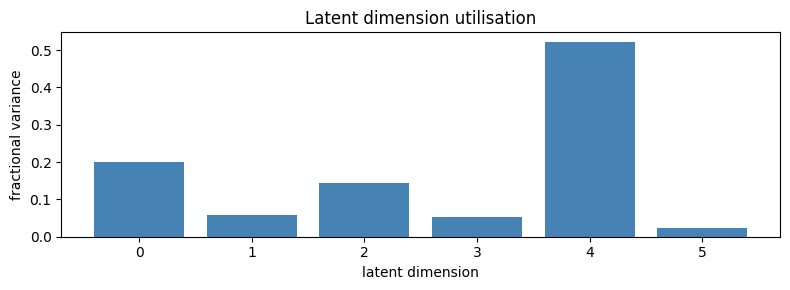

Entropy-based utilization: 0.754  (1.0 = uniform)


In [23]:
from sklearn.decomposition import PCA

# Encode full trajectories
use_train = True
traj_key = "train_trajs" if use_train else "test_trajs"
full_obs_key = "train_trajs_full" if use_train else "test_trajs_full"
label_prefix = "Train" if use_train else "Test"

trajs_obs = trajs[traj_key].sequence
trajs_full_arr = np.asarray(trajs[full_obs_key].sequence)

all_latents = []
with torch.no_grad():
    for i in tqdm(range(0, trajs_obs.shape[0], 8)):
        x = torch.as_tensor(trajs_obs[i:i+8]).float().to(device)
        z = lit_model.encode_trajectory(x)
        all_latents.append(z.cpu())
Z = torch.cat(all_latents, dim=0).numpy()

T_latent = Z.shape[1]
X_true = trajs_full_arr[:, -T_latent:, :]
Z_flat = Z.reshape(-1, Z.shape[-1])
X_true_flat = X_true.reshape(-1, X_true.shape[-1])

# Per-dimension variance (latent utilization)
dim_var = Z_flat.var(axis=0)
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(dim_var)), dim_var / dim_var.sum(), color='steelblue')
ax.set_xlabel('latent dimension'); ax.set_ylabel('fractional variance')
ax.set_title('Latent dimension utilisation')
plt.tight_layout(); plt.show()

p = dim_var / dim_var.sum()
entropy = -np.sum(p * np.log(p + 1e-10))
n_latent = Z_flat.shape[-1]
utilization = entropy / math.log(n_latent)
print(f'Entropy-based utilization: {utilization:.3f}  (1.0 = uniform)')

Participation ratio — Latents: 1.097  |  True state (Train): 1.693


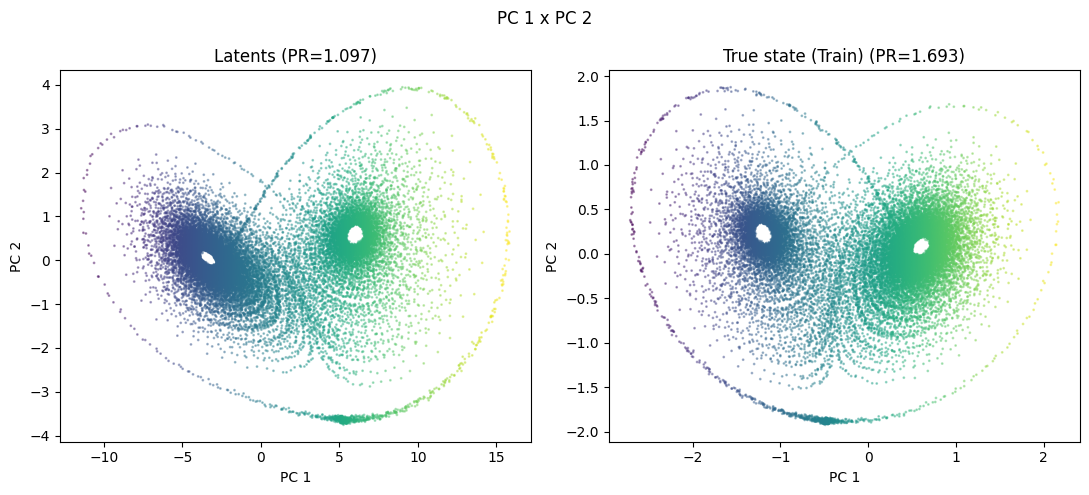

In [24]:
pr_latent = participation_ratio(Z_flat)
pr_true = participation_ratio(X_true_flat)
print(f"Participation ratio — Latents: {pr_latent:.3f}  |  True state ({label_prefix}): {pr_true:.3f}")

pca_latent = PCA(n_components=2).fit(Z_flat)
pca_true = PCA(n_components=2).fit(X_true_flat)
Z_pc = pca_latent.transform(Z_flat)
X_true_pc = pca_true.transform(X_true_flat)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].scatter(Z_pc[:, 0], Z_pc[:, 1], s=1, alpha=0.4, c=Z_pc[:, 0], cmap="viridis")
axes[0].set_xlabel("PC 1"); axes[0].set_ylabel("PC 2")
axes[0].set_title(f"Latents (PR={pr_latent:.3f})")
axes[1].scatter(X_true_pc[:, 0], X_true_pc[:, 1], s=1, alpha=0.4, c=X_true_pc[:, 0], cmap="viridis")
axes[1].set_xlabel("PC 1"); axes[1].set_ylabel("PC 2")
axes[1].set_title(f"True state ({label_prefix}) (PR={pr_true:.3f})")
fig.suptitle("PC 1 x PC 2", fontsize=12)
plt.tight_layout(); plt.show()

## 10. Lyapunov Exponent Comparison

In [25]:
lit_model.eval()
lit_model = lit_model.to(device)

with torch.no_grad():
    traj_full = torch.as_tensor(trajs['test_trajs'].sequence).float().to(device)
    n_test_trajs = traj_full.shape[0]
    T_full = traj_full.shape[1]
    print(f"Using {n_test_trajs} full-length test trajectories, T={T_full} each")

    z_full = lit_model.encode_trajectory(traj_full)

    all_pred_lyap = []
    for i in range(n_test_trajs):
        jacs_i = lit_model.compute_jacobians(z_full[i:i+1])[0]
        le_i = LitLatentJacobianODE.compute_lyapunov_exponents(jacs_i.cpu(), dt)
        all_pred_lyap.append(le_i)
        if i < 3:
            print(f"  Traj {i}: {le_i.numpy()}")

    all_pred_lyap = torch.stack(all_pred_lyap)
    pred_lyap = all_pred_lyap.mean(dim=0)
    pred_lyap_std = all_pred_lyap.std(dim=0)

print(f"\nPredicted Lyapunov exponents (mean +/- std over {n_test_trajs} trajs):")
for i, (le, std) in enumerate(zip(pred_lyap, pred_lyap_std)):
    print(f"  lambda_{i+1} = {le.item():+.4f} +/- {std.item():.4f}")
print(f"\nTrue Lorenz: {TRUE_LYAPUNOV}")

Using 3 full-length test trajectories, T=1200 each
  Traj 0: [  0.61183816  -0.03105705  -5.7463765   -7.2098665   -9.19361
 -16.58622   ]
  Traj 1: [  0.687492    -0.14589447  -5.702356    -7.1701813   -9.131492
 -16.55816   ]
  Traj 2: [  0.67925197  -0.12145279  -5.723382    -7.1834526   -9.167541
 -16.561272  ]

Predicted Lyapunov exponents (mean +/- std over 3 trajs):
  lambda_1 = +0.6595 +/- 0.0415
  lambda_2 = -0.0995 +/- 0.0605
  lambda_3 = -5.7240 +/- 0.0220
  lambda_4 = -7.1878 +/- 0.0202
  lambda_5 = -9.1642 +/- 0.0312
  lambda_6 = -16.5686 +/- 0.0154

True Lorenz: [0.91, 0.0, -14.57]


/tmp/ipykernel_3395548/1993737365.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  traj_raw = np.array(traj_full_np) * sigma_norm + mu_val


Empirical true Lyapunov exponents (mean +/- std):
  lambda_1 = +0.3846 +/- 0.0251
  lambda_2 = -0.1716 +/- 0.0444
  lambda_3 = -13.8799 +/- 0.0398


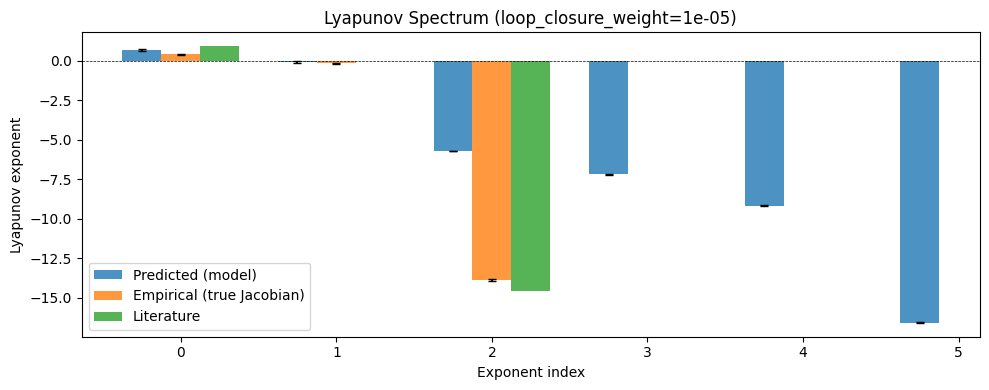

In [26]:
# Empirical true Lyapunov exponents from the analytical Jacobian
mu_val = best_cfg.data.postprocessing.mu
sigma_norm = best_cfg.data.postprocessing.sigma

traj_full_np = trajs['test_trajs'].sequence
traj_raw = np.array(traj_full_np) * sigma_norm + mu_val

all_empirical_lyap = []
for i in range(n_test_trajs):
    jacs_np = eq.jac(traj_raw[i], t=0)
    jacs_t = torch.as_tensor(jacs_np).float()
    le_i = LitLatentJacobianODE.compute_lyapunov_exponents(jacs_t, dt)
    all_empirical_lyap.append(le_i)

all_empirical_lyap = torch.stack(all_empirical_lyap)
empirical_lyap = all_empirical_lyap.mean(dim=0)
empirical_lyap_std = all_empirical_lyap.std(dim=0)

print(f"Empirical true Lyapunov exponents (mean +/- std):")
for i, (le, std) in enumerate(zip(empirical_lyap, empirical_lyap_std)):
    print(f"  lambda_{i+1} = {le.item():+.4f} +/- {std.item():.4f}")

# Bar chart
pred_np = pred_lyap.numpy()
pred_std_np = pred_lyap_std.numpy()
emp_np = empirical_lyap.numpy()
emp_std_np = empirical_lyap_std.numpy()
n_plot = max(len(pred_np), len(emp_np), len(TRUE_LYAPUNOV))
x_idx = np.arange(n_plot)
bar_w = 0.25

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x_idx[:len(pred_np)] - bar_w, pred_np, width=bar_w,
       yerr=pred_std_np, capsize=3, label="Predicted (model)", alpha=0.8)
ax.bar(x_idx[:len(emp_np)], emp_np, width=bar_w,
       yerr=emp_std_np, capsize=3, label="Empirical (true Jacobian)", alpha=0.8)
ax.bar(x_idx[:len(TRUE_LYAPUNOV)] + bar_w, TRUE_LYAPUNOV, width=bar_w,
       label="Literature", alpha=0.8)
ax.axhline(y=0, color='k', linestyle='--', lw=0.5)
ax.set_xticks(x_idx)
ax.set_xlabel("Exponent index"); ax.set_ylabel("Lyapunov exponent")
ax.set_title(f"Lyapunov Spectrum (loop_closure_weight={best_lambda})")
ax.legend()
plt.tight_layout(); plt.show()

## 11. Generated Predictions (Latent & Observation Space)

Roll out the model (no teacher forcing) and compare latent + observation predictions to ground truth.

Batch nMSE: 0.117013


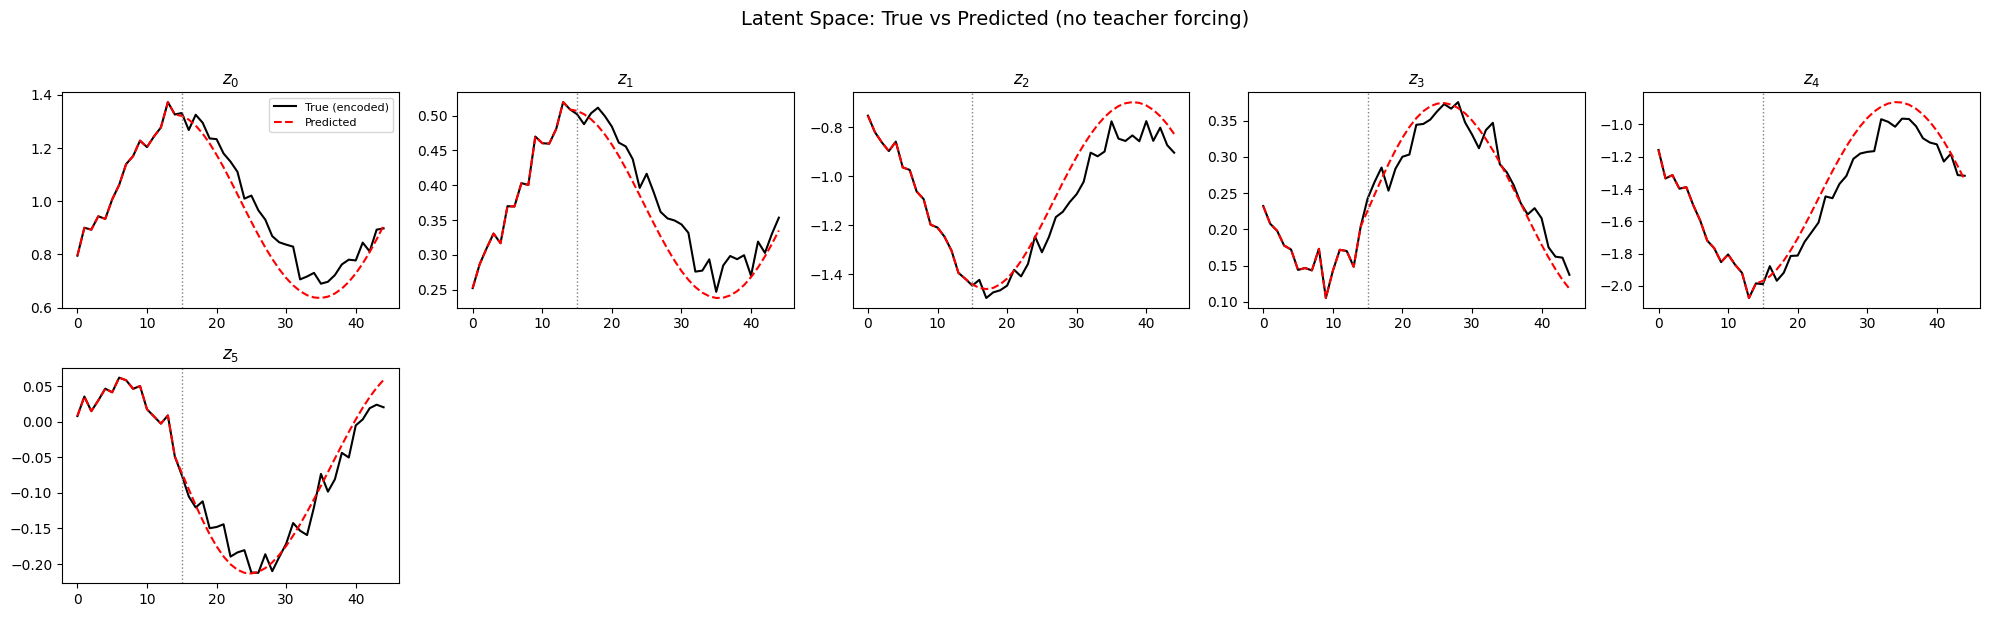

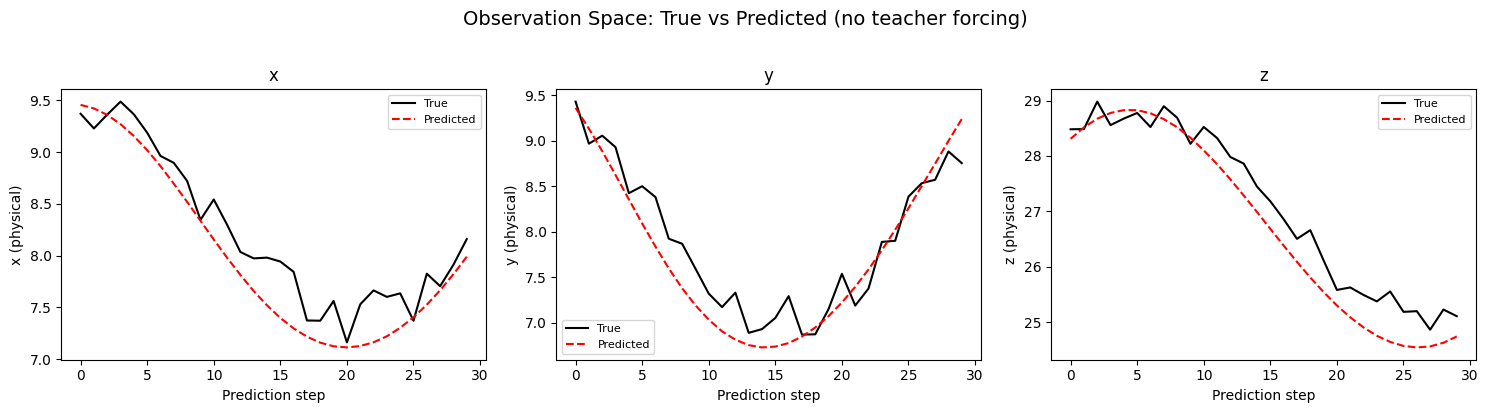

In [27]:
n_test = test_dl.dataset.sequence.shape[0]
win_idx = np.random.randint(0, n_test)
traj_obs = torch.as_tensor(test_dl.dataset.sequence[win_idx:win_idx+1]).float().to(device)

with torch.no_grad():
    result_dict = lit_model.trajectory_model_step(
        traj_obs, alpha_teacher_forcing=0.0, obs_noise_scale=0, return_decoded=True,
    )

z_pred_full = result_dict['outputs']
decoded_pred = result_dict['decoded']
obs_targets = result_dict['targets']
batch_nmse = nmse_fn(obs_targets, decoded_pred).item()
print(f"Batch nMSE: {batch_nmse:.6f}")

with torch.no_grad():
    z_true_full = lit_model.encode_trajectory(traj_obs)
traj_init_steps = lit_model.jacobianODEint_kwargs.get('traj_init_steps', 15)
jac_window_len = traj_init_steps + lit_model.prediction_steps

z_pred_win = z_pred_full[0].detach().cpu().numpy()
z_true_win = z_true_full[0, :jac_window_len].detach().cpu().numpy()
obs_pred_0 = decoded_pred[0].detach().cpu().numpy()
obs_true_0 = obs_targets[0].detach().cpu().numpy()

# Latent space predictions
n_latent = z_pred_win.shape[-1]
n_cols = min(5, n_latent)
n_rows = (n_latent + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), squeeze=False)
t_steps = np.arange(jac_window_len)
for i in range(n_latent):
    ax = axes[i // n_cols, i % n_cols]
    ax.plot(t_steps, z_true_win[:, i], 'k-', lw=1.5, label='True (encoded)')
    ax.plot(t_steps, z_pred_win[:, i], 'r--', lw=1.5, label='Predicted')
    ax.axvline(x=traj_init_steps, color='gray', ls=':', lw=1)
    ax.set_title(f'$z_{{{i}}}$')
    if i == 0: ax.legend(fontsize=8)
for i in range(n_latent, n_rows*n_cols):
    axes[i // n_cols, i % n_cols].set_visible(False)
fig.suptitle('Latent Space: True vs Predicted (no teacher forcing)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Observation space predictions
dim_labels = ['x', 'y', 'z']
t_pred = np.arange(obs_pred_0.shape[0])
D_obs = obs_pred_0.shape[-1]
obs_pred_phys = obs_pred_0 * sigma + mu
obs_true_phys = obs_true_0 * sigma + mu

fig, axes_p = plt.subplots(1, min(D_obs, 3), figsize=(5*min(D_obs,3), 4), squeeze=False)
for d in range(min(D_obs, 3)):
    ax = axes_p[0, d]
    label = dim_labels[d] if d < len(dim_labels) else f'dim {d}'
    ax.plot(t_pred, obs_true_phys[:, d], 'k-', lw=1.5, label='True')
    ax.plot(t_pred, obs_pred_phys[:, d], 'r--', lw=1.5, label='Predicted')
    ax.set_xlabel('Prediction step'); ax.set_ylabel(f'{label} (physical)')
    ax.set_title(label); ax.legend(fontsize=8)
fig.suptitle('Observation Space: True vs Predicted (no teacher forcing)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

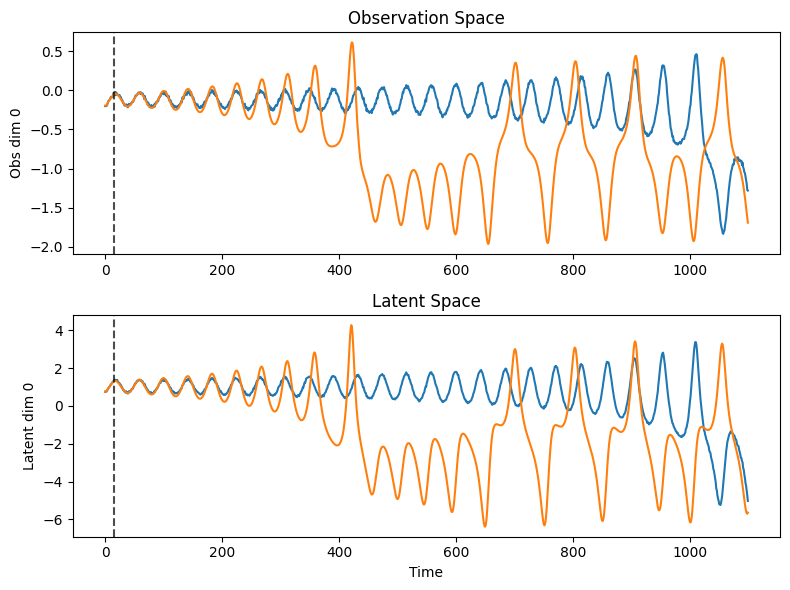

In [28]:
traj_long = trajs['test_trajs'].sequence[[0]].to(device)[:, 100:]
with torch.no_grad():
    rd_long = lit_model.trajectory_model_step(
        traj_long, alpha_teacher_forcing=0.0, obs_noise_scale=0, return_decoded=True, strided=False,
    )
    encoded = lit_model.encode_trajectory(traj_long)
    recon = lit_model.decode_trajectory(encoded)
    decoded_v2 = lit_model.decode_trajectory(rd_long['outputs'])

fig, axs = plt.subplots(2, 1, figsize=(8, 6))
axs[0].plot(traj_long[0, :, 0].cpu(), label="True Observation")
axs[0].plot(decoded_v2[0, :, 0].cpu(), label="Predicted Observation")
axs[0].axvline(15, color='k', linestyle='--', alpha=0.7, label="Prediction Start")
axs[0].set_title("Observation Space"); axs[0].set_ylabel("Obs dim 0")
axs[1].plot(encoded[0, :, 0].cpu(), label="Encoded Latent")
axs[1].plot(rd_long['outputs'][0, :, 0].cpu(), label="Predicted Latent")
axs[1].axvline(15, color='k', linestyle='--', alpha=0.7, label="Prediction Start")
axs[1].set_title("Latent Space"); axs[1].set_ylabel("Latent dim 0"); axs[1].set_xlabel("Time")
plt.tight_layout(); plt.show()

## 12. Prediction Diagnostics — Per-Window nMSE & One-Step vs Free-Running

Compute per-window normalized MSE across test trajectories, then compare
one-step (teacher-forced) vs free-running MASE.

In [29]:
traj_init_steps = lit_model.jacobianODEint_kwargs.get('traj_init_steps', 15)
jac_window_len = traj_init_steps + lit_model.prediction_steps
stride = lit_model.jac_window_stride

N_TEST_TRAJS = min(3, trajs['test_trajs'].sequence.shape[0])

all_decoded_pred = []
all_obs_targets = []
all_z_pred = []
all_z_true_windows = []
all_per_window_nmse = []

for t_idx in range(N_TEST_TRAJS):
    traj_obs_i = torch.as_tensor(
        trajs['test_trajs'].sequence[t_idx:t_idx+1]
    ).float().to(device)
    with torch.no_grad():
        rd = lit_model.trajectory_model_step(
            traj_obs_i, alpha_teacher_forcing=0.0, obs_noise_scale=0, return_decoded=True,
        )
        z_true_i = lit_model.encode_trajectory(traj_obs_i)

    dec_pred = rd['decoded'].cpu()
    obs_tgt = rd['targets'].cpu()
    z_pred_i = rd['outputs'].cpu()

    N_win = dec_pred.shape[0]
    mean_var = obs_tgt.reshape(-1, obs_tgt.shape[-1]).var(dim=0).mean().clamp(min=1e-8)
    for w in range(N_win):
        w_mse = (dec_pred[w] - obs_tgt[w]).pow(2).mean()
        all_per_window_nmse.append((w_mse / mean_var).item())

    z_true_np = z_true_i[0].cpu()
    T_prime = z_true_np.shape[0]
    n_windows = max(1, (T_prime - jac_window_len) // stride + 1)
    for w in range(n_windows):
        start = w * stride
        if start + jac_window_len <= T_prime:
            all_z_true_windows.append(z_true_np[start:start + jac_window_len].numpy())

    all_decoded_pred.append(dec_pred.numpy())
    all_obs_targets.append(obs_tgt.numpy())
    all_z_pred.append(z_pred_i.numpy())

all_decoded_pred = np.concatenate(all_decoded_pred, axis=0)
all_obs_targets = np.concatenate(all_obs_targets, axis=0)
all_z_pred = np.concatenate(all_z_pred, axis=0)
all_z_true_windows = np.array(all_z_true_windows)
all_per_window_nmse = np.array(all_per_window_nmse)

print(f"Total windows: {len(all_per_window_nmse)}")
print(f"nMSE — min: {all_per_window_nmse.min():.6f}, median: {np.median(all_per_window_nmse):.6f}, "
      f"mean: {all_per_window_nmse.mean():.6f}, max: {all_per_window_nmse.max():.6f}")

Total windows: 696
nMSE — min: 0.001109, median: 0.004482, mean: 0.021640, max: 1.334978


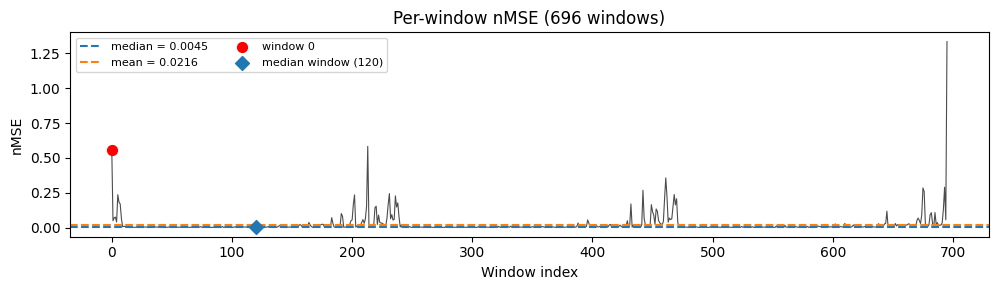

In [30]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(all_per_window_nmse, 'k-', lw=0.8, alpha=0.7)
ax.axhline(np.median(all_per_window_nmse), color='C0', ls='--', lw=1.5,
           label=f'median = {np.median(all_per_window_nmse):.4f}')
ax.axhline(all_per_window_nmse.mean(), color='C1', ls='--', lw=1.5,
           label=f'mean = {all_per_window_nmse.mean():.4f}')
median_idx = np.argsort(all_per_window_nmse)[len(all_per_window_nmse) // 2]
ax.scatter([0], [all_per_window_nmse[0]], c='red', s=50, zorder=5, label=f'window 0')
ax.scatter([median_idx], [all_per_window_nmse[median_idx]], c='C0', s=50, zorder=5,
           marker='D', label=f'median window ({median_idx})')
ax.set_xlabel('Window index'); ax.set_ylabel('nMSE')
ax.set_title(f'Per-window nMSE ({len(all_per_window_nmse)} windows)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

In [31]:
# Compare one-step vs free-running MASE
all_decoded_pred_onestep = []
all_obs_targets_onestep = []

for t_idx in range(N_TEST_TRAJS):
    traj_obs_i = torch.as_tensor(
        trajs['test_trajs'].sequence[t_idx:t_idx+1]
    ).float().to(device)
    with torch.no_grad():
        rd1 = lit_model.trajectory_model_step(
            traj_obs_i, alpha_teacher_forcing=1.0, obs_noise_scale=0, return_decoded=True,
        )
    all_decoded_pred_onestep.append(rd1['decoded'].cpu().numpy())
    all_obs_targets_onestep.append(rd1['targets'].cpu().numpy())

all_decoded_pred_onestep = np.concatenate(all_decoded_pred_onestep, axis=0)
all_obs_targets_onestep = np.concatenate(all_obs_targets_onestep, axis=0)

mase_freerun = mase(all_obs_targets, all_decoded_pred)
mase_onestep = mase(all_obs_targets_onestep, all_decoded_pred_onestep)

print("=" * 60)
print("One-step vs Free-running MASE")
print("=" * 60)
print(f"  MASE (one-step, alpha=1): {mase_onestep:.4f}")
print(f"  MASE (free-run, alpha=0): {mase_freerun:.4f}")

One-step vs Free-running MASE
  MASE (one-step, alpha=1): 0.3984
  MASE (free-run, alpha=0): 0.8808


Median-loss window: index=120, nMSE=0.004501


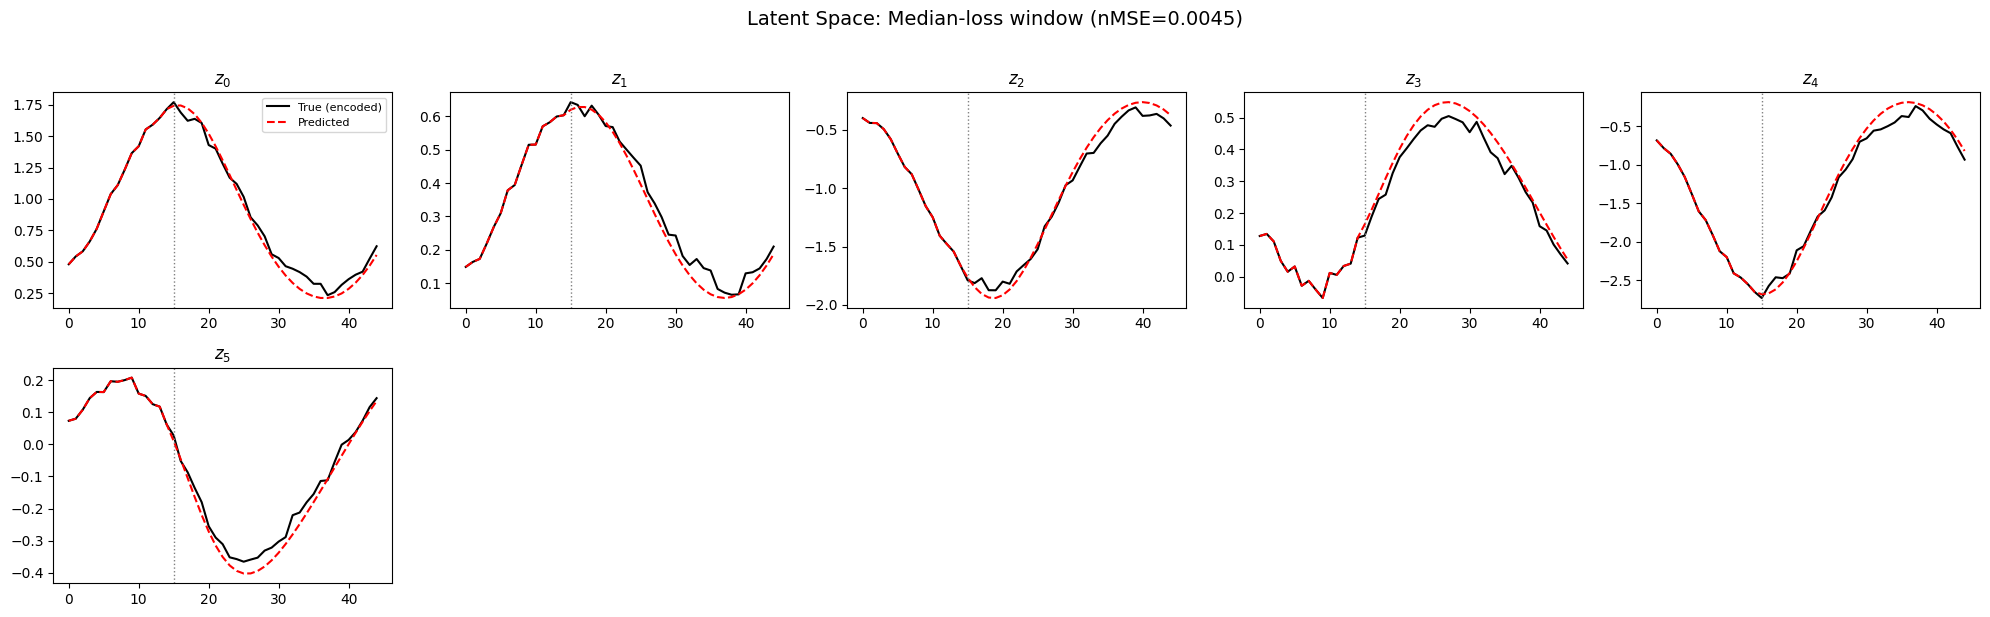

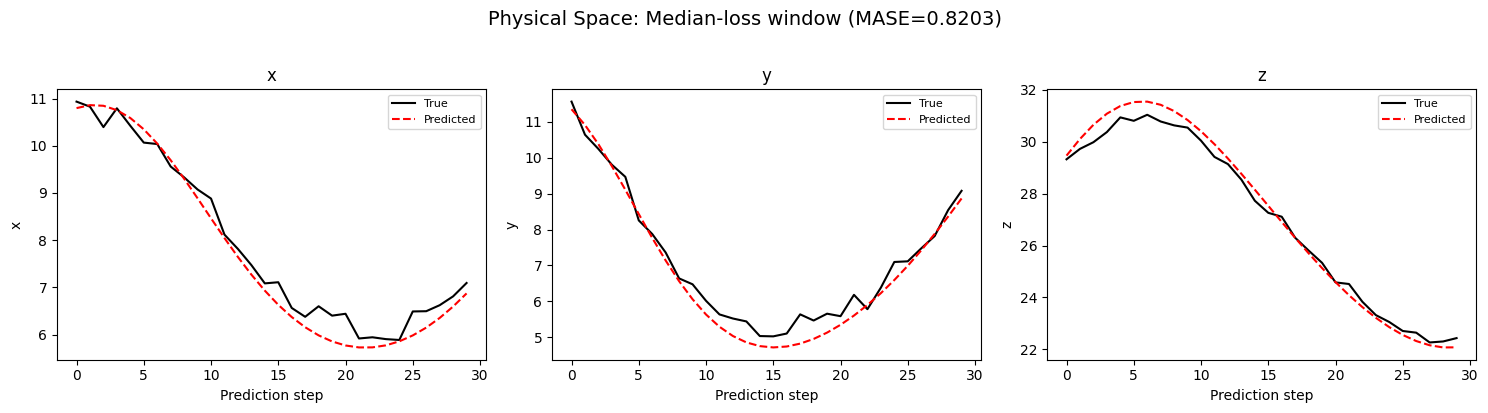

In [32]:
median_idx = int(np.argsort(all_per_window_nmse)[len(all_per_window_nmse) // 2])
print(f"Median-loss window: index={median_idx}, nMSE={all_per_window_nmse[median_idx]:.6f}")

z_pred_med = all_z_pred[median_idx]
z_true_med = all_z_true_windows[median_idx]
obs_pred_med = all_decoded_pred[median_idx]
obs_true_med = all_obs_targets[median_idx]

# Latent space
n_latent = z_pred_med.shape[-1]
n_cols = min(5, n_latent)
n_rows = (n_latent + n_cols - 1) // n_cols
t_steps_med = np.arange(jac_window_len)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), squeeze=False)
for i in range(n_latent):
    ax = axes[i // n_cols, i % n_cols]
    ax.plot(t_steps_med, z_true_med[:, i], 'k-', lw=1.5, label='True (encoded)')
    ax.plot(t_steps_med, z_pred_med[:, i], 'r--', lw=1.5, label='Predicted')
    ax.axvline(x=traj_init_steps, color='gray', ls=':', lw=1)
    ax.set_title(f'$z_{{{i}}}$')
    if i == 0: ax.legend(fontsize=8)
for i in range(n_latent, n_rows*n_cols):
    axes[i // n_cols, i % n_cols].set_visible(False)
fig.suptitle(f'Latent Space: Median-loss window (nMSE={all_per_window_nmse[median_idx]:.4f})',
             fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Observation space
obs_pred_phys_med = obs_pred_med * sigma + mu
obs_true_phys_med = obs_true_med * sigma + mu
D_obs_med = obs_pred_med.shape[-1]
t_pred_med = np.arange(obs_pred_med.shape[0])
fig, axes_p = plt.subplots(1, min(D_obs_med, 3), figsize=(5*min(D_obs_med,3), 4), squeeze=False)
for d in range(min(D_obs_med, 3)):
    ax = axes_p[0, d]
    label = dim_labels[d] if d < len(dim_labels) else f'dim {d}'
    ax.plot(t_pred_med, obs_true_phys_med[:, d], 'k-', lw=1.5, label='True')
    ax.plot(t_pred_med, obs_pred_phys_med[:, d], 'r--', lw=1.5, label='Predicted')
    ax.set_xlabel('Prediction step'); ax.set_ylabel(f'{label}'); ax.set_title(label)
    ax.legend(fontsize=8)
window_mase = mase(obs_true_phys_med, obs_pred_phys_med)
fig.suptitle(f'Physical Space: Median-loss window (MASE={window_mase:.4f})', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 13. Loop Closure Decomposition (PCA-Based)

Decomposes loop closure error into on-manifold and off-manifold components
using PCA of the latent space.

Latent dim: 6
PCA variance explained: ['0.9328', '0.0563', '0.0102', '0.0006', '0.0001', '0.0000']
On-manifold rank k = 2 (captures 98.91% of variance)

Block                      Mean Frob Norm   Std Frob Norm
------------------------------------------------------------
on->on                            18.9710          4.2441
off->on                           30.0900          2.7212
on->off                            6.2168          2.3497
off->off                          19.8881          1.3748

Loop closure error decomposition:
  Total:        4.3737
  On-manifold:  2.2458  (51.3%)
  Off-manifold: 2.1279  (48.7%)


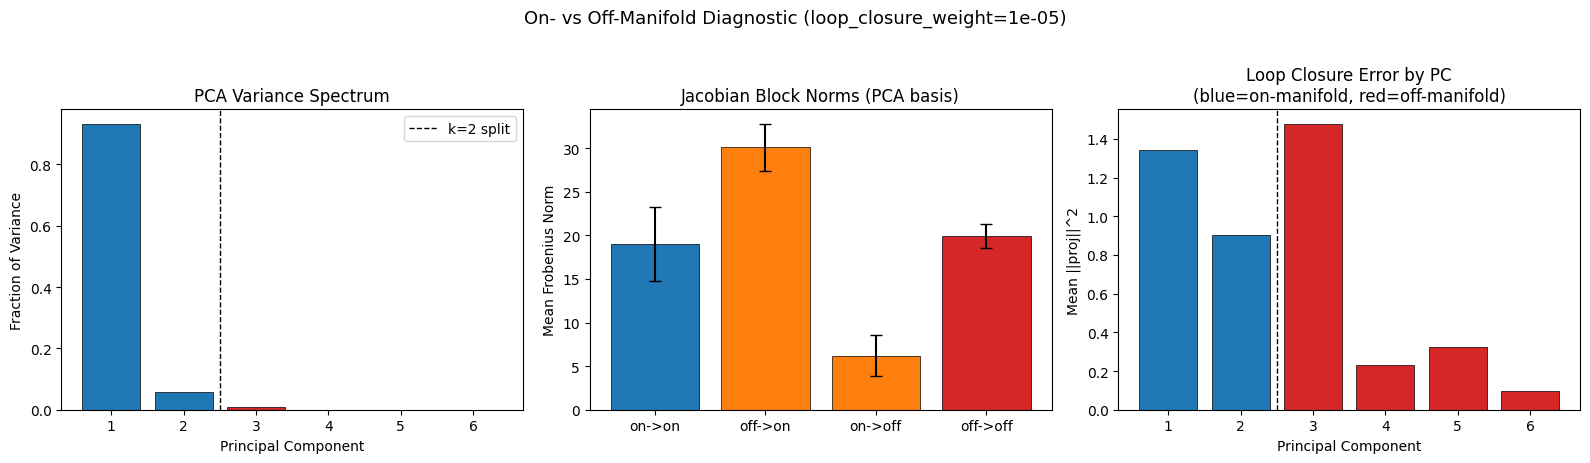

Off-manifold fraction: 48.7% — error spread across manifold dimensions


In [33]:
lit_model.eval()
lit_model = lit_model.to(device)

# 1. Encode full test trajectories and compute global PCA
with torch.no_grad():
    traj_full_lc = torch.as_tensor(trajs['test_trajs'].sequence).float().to(device)
    z_full_lc = lit_model.encode_trajectory(traj_full_lc)
    D_latent = z_full_lc.shape[-1]

z_flat_lc = z_full_lc.reshape(-1, D_latent).float()
z_mean_lc = z_flat_lc.mean(0)
z_centered_lc = z_flat_lc - z_mean_lc

U_lc, S_lc, Vt_lc = torch.linalg.svd(z_centered_lc, full_matrices=False)
var_explained = (S_lc ** 2) / (S_lc ** 2).sum()
cumvar = var_explained.cumsum(0)

k = int((cumvar < 0.95).sum().item()) + 1
k = max(k, 2)

print(f"Latent dim: {D_latent}")
print(f"PCA variance explained: {[f'{v:.4f}' for v in var_explained.cpu().tolist()]}")
print(f"On-manifold rank k = {k} (captures {cumvar[k-1].item():.2%} of variance)")

V_on = Vt_lc[:k]
V_off = Vt_lc[k:]

# 2. Jacobian block decomposition in PCA basis
with torch.no_grad():
    jacs_lc = lit_model.compute_jacobians(z_full_lc)
jacs_flat_lc = jacs_lc.reshape(-1, D_latent, D_latent).float()
Vt_full = Vt_lc.to(jacs_flat_lc.device)
J_pca = Vt_full @ jacs_flat_lc @ Vt_full.T

J_on_on = J_pca[:, :k, :k]
J_on_off = J_pca[:, :k, k:]
J_off_on = J_pca[:, k:, :k]
J_off_off = J_pca[:, k:, k:]

block_names = ['on->on', 'off->on', 'on->off', 'off->off']
blocks = [J_on_on, J_on_off, J_off_on, J_off_off]

print(f"\n{'Block':<25s} {'Mean Frob Norm':>15s} {'Std Frob Norm':>15s}")
print("-" * 60)
for name, block in zip(block_names, blocks):
    fnorms = torch.linalg.norm(block, dim=(-2, -1), ord='fro')
    print(f"{name:<25s} {fnorms.mean().item():>15.4f} {fnorms.std().item():>15.4f}")

# 3. Loop closure error decomposition
with torch.no_grad():
    lc_kwargs = {}
    for attr in ['n_loops', 'n_loop_pts', 'loop_path', 'loop_closure_interp_pts',
                 'loop_closure_int_method', 'mix_trajectories']:
        if hasattr(lit_model, attr):
            lc_kwargs[attr.replace('loop_closure_int_method', 'int_method')] = getattr(lit_model, attr)

    all_loop_int = []
    n_lc_batches = min(20, len(val_dl))
    for i, batch in enumerate(val_dl):
        if i >= n_lc_batches:
            break
        if isinstance(batch, (list, tuple)):
            batch = batch[0]
        batch = batch.to(device).type(lit_model.dtype)
        z_batch = lit_model.encode_trajectory(batch)
        loop_int = loop_closure(
            z_batch, lit_model.compute_jacobians, dt=lit_model.dt,
            n_loops=lc_kwargs.get('n_loops'),
            n_loop_pts=lc_kwargs.get('n_loop_pts'),
            loop_path=lc_kwargs.get('loop_path', 'line'),
            loop_closure_interp_pts=lc_kwargs.get('loop_closure_interp_pts', 2),
            mix_trajectories=lc_kwargs.get('mix_trajectories', True),
            int_method=lc_kwargs.get('int_method', 'Trapezoid'),
        )
        all_loop_int.append(loop_int.float().cpu())
    all_loop_int = torch.cat(all_loop_int, dim=0)

V_on_cpu = V_on.cpu()
V_off_cpu = V_off.cpu()
loop_on = all_loop_int @ V_on_cpu.T
loop_off = all_loop_int @ V_off_cpu.T

sq_norm_total = (all_loop_int ** 2).sum(dim=-1)
sq_norm_on = (loop_on ** 2).sum(dim=-1)
sq_norm_off = (loop_off ** 2).sum(dim=-1)
mean_sq_total = sq_norm_total.mean().item()
mean_sq_on = sq_norm_on.mean().item()
mean_sq_off = sq_norm_off.mean().item()

mse_per_pc = []
for i in range(D_latent):
    proj_i = all_loop_int @ Vt_lc[i].cpu()
    mse_per_pc.append((proj_i ** 2).mean().item())

print(f"\nLoop closure error decomposition:")
print(f"  Total:        {mean_sq_total:.4f}")
print(f"  On-manifold:  {mean_sq_on:.4f}  ({mean_sq_on/mean_sq_total:.1%})")
print(f"  Off-manifold: {mean_sq_off:.4f}  ({mean_sq_off/mean_sq_total:.1%})")

# 4. Visualization
fig, axes_lc = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes_lc[0]
x_pc = np.arange(1, D_latent + 1)
colors_pc = ['tab:blue' if i < k else 'tab:red' for i in range(D_latent)]
ax.bar(x_pc, var_explained.cpu().numpy(), color=colors_pc, edgecolor='k', lw=0.5)
ax.axvline(k + 0.5, color='k', ls='--', lw=1, label=f'k={k} split')
ax.set_xlabel('Principal Component'); ax.set_ylabel('Fraction of Variance')
ax.set_title('PCA Variance Spectrum'); ax.legend()

ax = axes_lc[1]
block_means = [torch.linalg.norm(b, dim=(-2,-1), ord='fro').mean().item() for b in blocks]
block_stds = [torch.linalg.norm(b, dim=(-2,-1), ord='fro').std().item() for b in blocks]
bar_colors_bl = ['tab:blue', 'tab:orange', 'tab:orange', 'tab:red']
ax.bar(block_names, block_means, yerr=block_stds, color=bar_colors_bl,
       edgecolor='k', lw=0.5, capsize=4)
ax.set_ylabel('Mean Frobenius Norm'); ax.set_title('Jacobian Block Norms (PCA basis)')

ax = axes_lc[2]
bar_colors_pc2 = ['tab:blue' if i < k else 'tab:red' for i in range(D_latent)]
ax.bar(x_pc, mse_per_pc, color=bar_colors_pc2, edgecolor='k', lw=0.5)
ax.axvline(k + 0.5, color='k', ls='--', lw=1)
ax.set_xlabel('Principal Component'); ax.set_ylabel('Mean ||proj||^2')
ax.set_title('Loop Closure Error by PC\n(blue=on-manifold, red=off-manifold)')

plt.suptitle(f'On- vs Off-Manifold Diagnostic (loop_closure_weight={best_lambda})', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

frac_off = mean_sq_off / mean_sq_total
if frac_off > 0.8:
    print(f"Off-manifold fraction: {frac_off:.1%} — STRONG off-manifold dominance")
elif frac_off > 0.5:
    print(f"Off-manifold fraction: {frac_off:.1%} — MODERATE off-manifold dominance")
else:
    print(f"Off-manifold fraction: {frac_off:.1%} — error spread across manifold dimensions")

## 14. Encoder-Jacobian Tangent/Normal Decomposition

Uses the encoder Jacobian (pushforward) to define local tangent and normal spaces,
rather than global PCA.

Encoder Jacobian: 6 x 3
Tangent space dim: 3, Normal space dim: 3

Encoder singular values (mean +/- std over 2000 points):
  sigma_1 = 4.9946 +/- 0.4191
  sigma_2 = 1.9560 +/- 0.1116
  sigma_3 = 1.3625 +/- 0.2011

Dynamics Jacobian blocks (encoder-Jacobian basis):
Block                   Mean Frob     Std Frob
------------------------------------------------
tan->tan                  37.6958       2.5928
norm->tan                 10.5957       1.1319
tan->norm                  1.6253       0.6781
norm->norm                13.6568       2.0294

Encoder-Jacobian loop closure decomposition:
  Total:   4.1157
  Tangent: 3.5564  (86.4%)
  Normal:  0.5593  (13.6%)


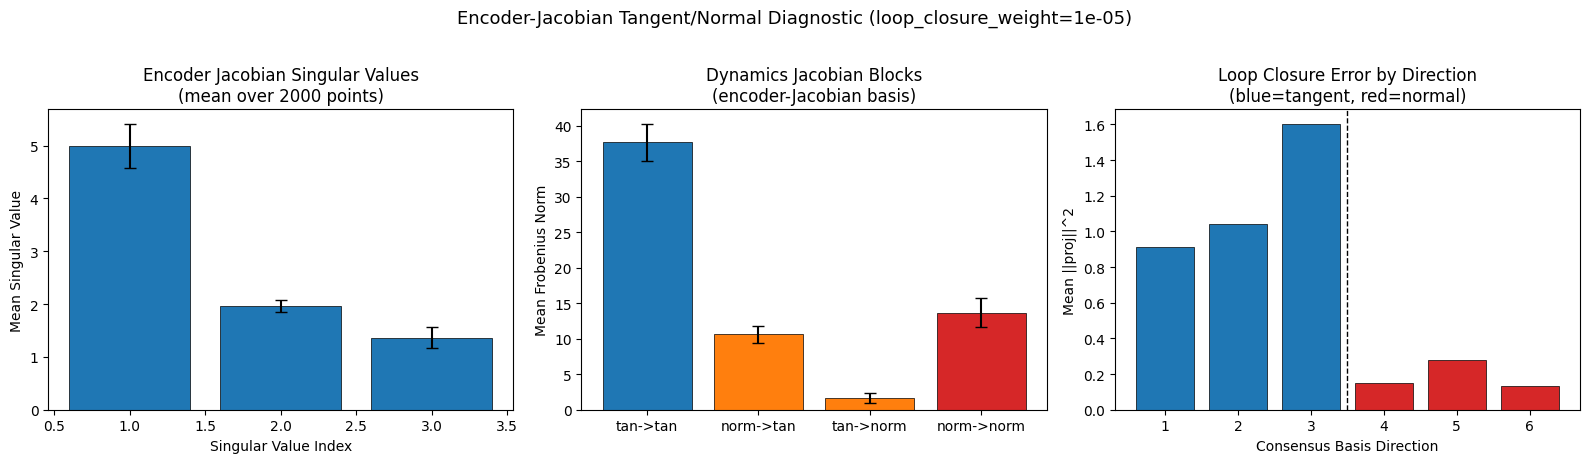


Comparison: PCA off-manifold=48.7%, Encoder normal=13.6%


In [34]:
with torch.no_grad():
    traj_full_enc = torch.as_tensor(trajs['test_trajs'].sequence).float().to(device)
    z_full_enc = lit_model.encode_trajectory(traj_full_enc)
    D_latent_enc = z_full_enc.shape[-1]
    D_obs_enc = traj_full_enc.shape[-1]

obs_flat = traj_full_enc.reshape(-1, D_obs_enc)
z_flat_enc = z_full_enc.reshape(-1, D_latent_enc)

N_total = obs_flat.shape[0]
N_jac = min(2000, N_total)
jac_idx = torch.randperm(N_total, device=device)[:N_jac]
obs_sample = obs_flat[jac_idx]
z_sample = z_flat_enc[jac_idx]

def compute_encoder_jacobians(model, obs_points, batch_size=512):
    model.eval()
    all_jacs = []
    for start in range(0, len(obs_points), batch_size):
        x = obs_points[start:start + batch_size].detach().clone().requires_grad_(True)
        z = model.encoder.encode(x.unsqueeze(1)).squeeze(1)
        D_lat = z.shape[-1]
        cols = []
        for j in range(D_lat):
            g_out = torch.zeros_like(z)
            g_out[:, j] = 1.0
            (g,) = torch.autograd.grad(
                z, x, grad_outputs=g_out,
                retain_graph=(j < D_lat - 1), create_graph=False,
            )
            cols.append(g)
        all_jacs.append(torch.stack(cols, dim=1).detach())
    return torch.cat(all_jacs, dim=0)

enc_jacs = compute_encoder_jacobians(lit_model, obs_sample)
U_enc, S_enc, Vh_enc = torch.linalg.svd(enc_jacs, full_matrices=True)

r = min(D_latent_enc, D_obs_enc)
print(f"Encoder Jacobian: {D_latent_enc} x {D_obs_enc}")
print(f"Tangent space dim: {r}, Normal space dim: {D_latent_enc - r}")

S_mean = S_enc.mean(0).cpu()
S_std = S_enc.std(0).cpu()
print(f"\nEncoder singular values (mean +/- std over {N_jac} points):")
for i in range(r):
    print(f"  sigma_{i+1} = {S_mean[i].item():.4f} +/- {S_std[i].item():.4f}")

# Dynamics Jacobian block decomposition
with torch.no_grad():
    J_dyn = lit_model.compute_jacobians(z_sample.unsqueeze(0))[0]

J_loc = U_enc.transpose(-2, -1) @ J_dyn @ U_enc
J_tt = J_loc[:, :r, :r]
J_tn = J_loc[:, :r, r:]
J_nt = J_loc[:, r:, :r]
J_nn = J_loc[:, r:, r:]

enc_block_names = ['tan->tan', 'norm->tan', 'tan->norm', 'norm->norm']
enc_blocks = [J_tt, J_tn, J_nt, J_nn]

print(f"\nDynamics Jacobian blocks (encoder-Jacobian basis):")
print(f"{'Block':<20s} {'Mean Frob':>12s} {'Std Frob':>12s}")
print("-" * 48)
for name, block in zip(enc_block_names, enc_blocks):
    fn = torch.linalg.norm(block, dim=(-2, -1), ord='fro')
    print(f"{name:<20s} {fn.mean().item():>12.4f} {fn.std().item():>12.4f}")

# Consensus tangent/normal basis for loop closure decomposition
U_tan = U_enc[:, :, :r]
P_tan_avg = (U_tan @ U_tan.transpose(-2, -1)).mean(0)
eigvals_cons, eigvecs_cons = torch.linalg.eigh(P_tan_avg)
eigvals_cons = eigvals_cons.flip(0)
eigvecs_cons = eigvecs_cons.flip(1)

V_tan_consensus = eigvecs_cons[:, :r]
V_nrm_consensus = eigvecs_cons[:, r:]

# Loop closure error decomposition
with torch.no_grad():
    all_loop_int_enc = []
    for i, batch in enumerate(val_dl):
        if i >= n_lc_batches:
            break
        if isinstance(batch, (list, tuple)):
            batch = batch[0]
        batch = batch.to(device).type(lit_model.dtype)
        z_batch = lit_model.encode_trajectory(batch)
        li = loop_closure(
            z_batch, lit_model.compute_jacobians, dt=lit_model.dt,
            n_loops=lc_kwargs.get('n_loops'),
            n_loop_pts=lc_kwargs.get('n_loop_pts'),
            loop_path=lc_kwargs.get('loop_path', 'line'),
            loop_closure_interp_pts=lc_kwargs.get('loop_closure_interp_pts', 2),
            mix_trajectories=lc_kwargs.get('mix_trajectories', True),
            int_method=lc_kwargs.get('int_method', 'Trapezoid'),
        )
        all_loop_int_enc.append(li.float().cpu())
    all_loop_int_enc = torch.cat(all_loop_int_enc, dim=0)

V_tan_cpu = V_tan_consensus.cpu()
V_nrm_cpu = V_nrm_consensus.cpu()
loop_tan = all_loop_int_enc @ V_tan_cpu
loop_nrm = all_loop_int_enc @ V_nrm_cpu

mean_total = (all_loop_int_enc ** 2).sum(dim=-1).mean().item()
mean_tan = (loop_tan ** 2).sum(dim=-1).mean().item()
mean_nrm = (loop_nrm ** 2).sum(dim=-1).mean().item()

print(f"\nEncoder-Jacobian loop closure decomposition:")
print(f"  Total:   {mean_total:.4f}")
print(f"  Tangent: {mean_tan:.4f}  ({mean_tan/mean_total:.1%})")
print(f"  Normal:  {mean_nrm:.4f}  ({mean_nrm/mean_total:.1%})")

# Visualization
fig, axes_enc = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes_enc[0]
x_sv = np.arange(1, r + 1)
ax.bar(x_sv, S_mean.numpy(), yerr=S_std.numpy(), color='tab:blue',
       edgecolor='k', lw=0.5, capsize=4)
ax.set_xlabel('Singular Value Index'); ax.set_ylabel('Mean Singular Value')
ax.set_title(f'Encoder Jacobian Singular Values\n(mean over {N_jac} points)')

ax = axes_enc[1]
enc_block_means = [torch.linalg.norm(b, dim=(-2,-1), ord='fro').mean().item() for b in enc_blocks]
enc_block_stds = [torch.linalg.norm(b, dim=(-2,-1), ord='fro').std().item() for b in enc_blocks]
enc_bar_colors = ['tab:blue', 'tab:orange', 'tab:orange', 'tab:red']
ax.bar(enc_block_names, enc_block_means, yerr=enc_block_stds,
       color=enc_bar_colors, edgecolor='k', lw=0.5, capsize=4)
ax.set_ylabel('Mean Frobenius Norm'); ax.set_title('Dynamics Jacobian Blocks\n(encoder-Jacobian basis)')

ax = axes_enc[2]
per_dir_mse_enc = []
for i in range(D_latent_enc):
    proj = all_loop_int_enc @ eigvecs_cons[:, i].cpu()
    per_dir_mse_enc.append((proj ** 2).mean().item())
x_dirs = np.arange(1, D_latent_enc + 1)
dir_colors = ['tab:blue' if i < r else 'tab:red' for i in range(D_latent_enc)]
ax.bar(x_dirs, per_dir_mse_enc, color=dir_colors, edgecolor='k', lw=0.5)
ax.axvline(r + 0.5, color='k', ls='--', lw=1)
ax.set_xlabel('Consensus Basis Direction'); ax.set_ylabel('Mean ||proj||^2')
ax.set_title('Loop Closure Error by Direction\n(blue=tangent, red=normal)')

plt.suptitle(f'Encoder-Jacobian Tangent/Normal Diagnostic (loop_closure_weight={best_lambda})',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

frac_nrm = mean_nrm / mean_total
print(f"\nComparison: PCA off-manifold={frac_off:.1%}, Encoder normal={frac_nrm:.1%}")

In [36]:
# ── Tangent-Space Lyapunov Exponents (J_tt, J_nn) & Encoder Variance Explained ──
# From the Tangent Spaces notebook: project Jacobians into encoder-Jacobian basis,
# extract J_tt (tangent→tangent) and J_nn (normal→normal) blocks, compute Lyapunov exponents.
# Also: variance explained by successive encoder tangent dimensions (dz projection).

n_delays_cfg = best_cfg.data.train_test_params.delay_embedding_params.n_delays
has_full_obs = (n_delays_cfg == 1) and (eq is not None)
# N_LYAP_TRAJ = min(3, trajs['test_trajs'].sequence.shape[0])
N_LYAP_TRAJ = min(6, trajs['test_trajs'].sequence.shape[0])
T_len = trajs['test_trajs'].sequence.shape[1]

# Get test trajectories and encode
test_seq = torch.as_tensor(trajs['test_trajs'].sequence).float().to(device)
z_trajs = lit_model.encode_trajectory(test_seq)  # (n_traj, T, n_latent)
n_obs = test_seq.shape[-1]
n_latent = z_trajs.shape[-1]
r = min(n_latent, n_obs)
n_normal = n_latent - r

def encode_point(x):
    """Map single observation (n_obs,) to latent (n_latent,)."""
    return lit_model.encoder.encode(x.unsqueeze(0).unsqueeze(1)).squeeze(0).squeeze(0)

# ── 1. Encoder tangent variance explained ──
# Project dz = z_{t+1} - z_t onto local tangent basis from SVD of encoder Jacobian
BATCH_JAC = 1000
N_diff = min(2000, (N_LYAP_TRAJ * (T_len - 1)))
x_t_flat = test_seq[:, :-1, :].reshape(-1, n_obs)[:N_diff].to(device)
x_next_flat = test_seq[:, 1:, :].reshape(-1, n_obs)[:N_diff].to(device)

with torch.no_grad():
    z_t = lit_model.encoder.encode(x_t_flat.unsqueeze(1)).squeeze(1)
    z_next = lit_model.encoder.encode(x_next_flat.unsqueeze(1)).squeeze(1)
    dz = z_next - z_t
    enc_jacs_diff = torch.func.vmap(torch.func.jacfwd(encode_point))(x_t_flat)
U_diff, _, _ = torch.linalg.svd(enc_jacs_diff, full_matrices=True)
tangent_projection = (dz.unsqueeze(1) @ U_diff).squeeze(1)

with torch.no_grad():
    squared_projections = tangent_projection ** 2
    variance_per_dim = squared_projections.mean(dim=0)
    total_variance = variance_per_dim.sum()
    variance_explained = variance_per_dim / total_variance
    cumulative_variance = torch.cumsum(variance_explained, dim=0)

print("=== Encoder Tangent Variance Explained (dz projection onto tangent basis) ===")
print(f"{'Dimension':<10} | {'Variance Explained':<20} | {'Cumulative'}")
print("-" * 45)
for i in range(len(variance_explained)):
    val = variance_explained[i].item() * 100
    cum = cumulative_variance[i].item() * 100
    print(f"Dim {i+1:<5} | {val:>17.4f}% | {cum:>10.4f}%")

# ── 2. Jacobian block norms (predicted; true when full obs) ──
# Encoder Jacobians per trajectory for projection
Jenc_trajs = []
for i in range(N_LYAP_TRAJ):
    obs_i = test_seq[i].to(device)  # (T, n_obs)
    jac_i = torch.func.vmap(torch.func.jacfwd(encode_point))(obs_i)
    Jenc_trajs.append(jac_i)
Jenc_trajs = torch.stack(Jenc_trajs).to(device)  # (n_traj, T, n_latent, n_obs)
U_enc_trajs, _, _ = torch.linalg.svd(Jenc_trajs, full_matrices=True)  # (n_traj, T, n_latent, n_latent)

# Predicted Jacobians
lyap_pred_tt_list, lyap_pred_nn_list = [], []
with torch.no_grad():
    for i in range(N_LYAP_TRAJ):
        z_i = z_trajs[i:i+1].to(device)
        J_pred_i = lit_model.compute_jacobians(z_i)[0]  # (T_len, n_latent, n_latent)
        U_i = U_enc_trajs[i]
        J_loc_pred = torch.einsum('tji,tjk,tkl->til', U_i, J_pred_i, U_i)
        J_tt_pred = J_loc_pred[:, :r, :r]
        J_nn_pred = J_loc_pred[:, r:, r:]
        lyap_pred_tt_list.append(LitLatentJacobianODE.compute_lyapunov_exponents(J_tt_pred, dt).cpu())
        lyap_pred_nn_list.append(LitLatentJacobianODE.compute_lyapunov_exponents(J_nn_pred, dt).cpu())

lyap_pred_tt = torch.stack(lyap_pred_tt_list)
lyap_pred_nn = torch.stack(lyap_pred_nn_list)
lyap_pred_tt_mean, lyap_pred_tt_std = lyap_pred_tt.mean(dim=0), lyap_pred_tt.std(dim=0)
lyap_pred_nn_mean, lyap_pred_nn_std = lyap_pred_nn.mean(dim=0), lyap_pred_nn.std(dim=0)

print("\n=== Tangent-space (J_tt) Lyapunov Exponents ===")
print(f"Tangent dimension r = {r}, trajectories: {N_LYAP_TRAJ}")
print("\nPredicted (J_tt block of latent Jacobian model):")
for j in range(r):
    print(f"  λ_{j+1} = {lyap_pred_tt_mean[j].item():+.4f} ± {lyap_pred_tt_std[j].item():.4f}")

print("\n=== Normal-space (J_nn) Lyapunov Exponents ===")
print(f"Normal dimension = {n_normal}")
print("\nPredicted (J_nn block of latent Jacobian model):")
for j in range(n_normal):
    print(f"  λ_{j+1} = {lyap_pred_nn_mean[j].item():+.4f} ± {lyap_pred_nn_std[j].item():.4f}")

# ── 3. True J_tt/J_nn Lyapunov (only when full observation) ──
if has_full_obs:
    mu_val = float(best_cfg.data.postprocessing.get('mu', 0.0))
    sigma_val = best_cfg.data.postprocessing.get('sigma', 1.0)
    sigma_arr = np.array(sigma_val) if np.isscalar(sigma_val) else np.atleast_1d(sigma_val)
    mu_arr = np.array(mu_val) if np.isscalar(mu_val) else np.atleast_1d(mu_val)
    adapter = lit_model.encoder

    def hessian_encode_point(x):
        return torch.func.jacfwd(torch.func.jacfwd(encode_point))(x)

    def _get_normalized_ode(x_norm, dtype, dev):
        x_raw = x_norm.detach().cpu().numpy() * sigma_arr + mu_arr
        f_raw = eq.rhs(x_raw, 0)
        J_f_raw = eq.jac(x_raw, 0)
        sigma_t = torch.tensor(sigma_arr, dtype=dtype, device=dev)
        f_t = torch.tensor(np.asarray(f_raw), dtype=dtype, device=dev)
        Jf_t = torch.tensor(np.asarray(J_f_raw), dtype=dtype, device=dev)
        if sigma_t.numel() == 1:
            return f_t / sigma_t, Jf_t
        return f_t / sigma_t, (1.0 / sigma_t).unsqueeze(1) * Jf_t * sigma_t.unsqueeze(0)

    def _true_latent_jac_core(x_norm, J_phi):
        f_norm, J_f_norm = _get_normalized_ode(x_norm, J_phi.dtype, J_phi.device)
        H_phi = torch.func.vmap(hessian_encode_point)(x_norm)
        Hf = torch.einsum("bijk,bj->bik", H_phi, f_norm)
        JJ = torch.bmm(J_phi, J_f_norm)
        J_phi_pinv = torch.linalg.pinv(J_phi)
        return torch.bmm(Hf + JJ, J_phi_pinv)

    # Precompute true Jacobians along trajectories
    BATCH_HESS = 100
    J_true_list = []
    for i in range(N_LYAP_TRAJ):
        obs_i = test_seq[i].to(device)
        J_phi_i = torch.func.vmap(torch.func.jacfwd(encode_point))(obs_i)
        true_J_i = []
        for start in range(0, T_len, BATCH_HESS):
            end = min(start + BATCH_HESS, T_len)
            x_b = obs_i[start:end]
            J_b = J_phi_i[start:end]
            true_J_i.append(_true_latent_jac_core(x_b, J_b).detach())
        J_true_list.append(torch.cat(true_J_i, dim=0))
    J_trajs_true = torch.stack(J_true_list)  # (n_traj, T, n_latent, n_latent)

    lyap_true_tt_list, lyap_true_nn_list = [], []
    with torch.no_grad():
        for i in range(N_LYAP_TRAJ):
            J_true_i = J_trajs_true[i].to(device)
            U_i = U_enc_trajs[i]
            J_loc_true = torch.einsum('tji,tjk,tkl->til', U_i, J_true_i, U_i)
            J_tt_true = J_loc_true[:, :r, :r]
            J_nn_true = J_loc_true[:, r:, r:]
            lyap_true_tt_list.append(LitLatentJacobianODE.compute_lyapunov_exponents(J_tt_true, dt).cpu())
            lyap_true_nn_list.append(LitLatentJacobianODE.compute_lyapunov_exponents(J_nn_true, dt).cpu())

    lyap_true_tt = torch.stack(lyap_true_tt_list)
    lyap_true_nn = torch.stack(lyap_true_nn_list)
    lyap_true_tt_mean = lyap_true_tt.mean(dim=0)
    lyap_true_nn_mean = lyap_true_nn.mean(dim=0)

    print("\n--- True Jacobian (full observation) ---")
    print("\nTrue (J_tt block of projected Jacobian):")
    for j in range(r):
        print(f"  λ_{j+1} = {lyap_true_tt_mean[j].item():+.4f}")
    print("\nTrue (J_nn block of projected Jacobian):")
    for j in range(n_normal):
        print(f"  λ_{j+1} = {lyap_true_nn_mean[j].item():+.4f}")
else:
    print("\n(Skipping true Jacobian: need full observation, n_delays=1)")

=== Encoder Tangent Variance Explained (dz projection onto tangent basis) ===
Dimension  | Variance Explained   | Cumulative
---------------------------------------------
Dim 1     |           84.0789% |    84.0789%
Dim 2     |           13.9332% |    98.0121%
Dim 3     |            1.9819% |    99.9940%
Dim 4     |            0.0015% |    99.9954%
Dim 5     |            0.0037% |    99.9991%
Dim 6     |            0.0009% |   100.0000%

=== Tangent-space (J_tt) Lyapunov Exponents ===
Tangent dimension r = 3, trajectories: 3

Predicted (J_tt block of latent Jacobian model):
  λ_1 = +0.8120 ± 0.0768
  λ_2 = -0.7597 ± 0.1060
  λ_3 = -15.1765 ± 0.0336

=== Normal-space (J_nn) Lyapunov Exponents ===
Normal dimension = 3

Predicted (J_nn block of latent Jacobian model):
  λ_1 = -5.8576 ± 0.0307
  λ_2 = -7.1486 ± 0.0233
  λ_3 = -9.9540 ± 0.0293

--- True Jacobian (full observation) ---

True (J_tt block of projected Jacobian):
  λ_1 = +0.5774
  λ_2 = -1.0404
  λ_3 = -13.1669

True (J_nn bloc

## 15. Smoothness Diagnostics

### First-Order Smoothness
Variance-normalized first-order finite differences.

### Second-Order Finite Differences (Linearity Penalty)
$$L_{\text{lin}} = \left\| (\hat{x}_{t+1} - \hat{x}_t) - (\hat{x}_t - \hat{x}_{t-1}) \right\|^2$$

In [37]:
# Compute latent and decoded predictions for smoothness analysis
batch_indices = np.random.choice(np.arange(len(test_dl.dataset.sequence)), size=(128,), replace=False)
sample_batch = test_dl.dataset.sequence[batch_indices]

with torch.no_grad():
    sample_batch_dev = sample_batch.to(device)
    latent_traj = lit_model.encode_trajectory(sample_batch_dev)
    traj_decoded = lit_model.decode_trajectory(latent_traj)

    traj_ret = lit_model.trajectory_model_step(sample_batch_dev, alpha_teacher_forcing=1.0, return_decoded=True)
    targets = traj_ret['targets']
    decoded = traj_ret['decoded']
    latent_targets = lit_model.encode_trajectory(targets)
    z_pred = traj_ret['outputs']

sample_batch = sample_batch.cpu()
latent_traj = latent_traj.cpu()
traj_decoded = traj_decoded.cpu()
targets = targets.cpu()
decoded = decoded.cpu()
latent_targets = latent_targets.cpu()
z_pred = z_pred.cpu()

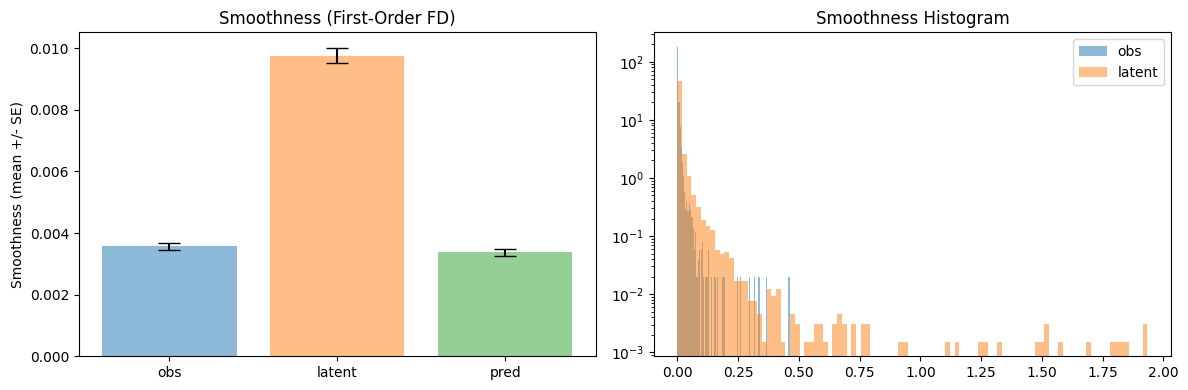

In [38]:
smoothness = (targets[:, 1:] - targets[:, :-1]).pow(2) / targets.var()
smoothness_latents = (latent_traj[:, 1:] - latent_traj[:, :-1]).pow(2) / latent_traj.var()
smoothness_pred = (decoded[:, 1:] - decoded[:, :-1]).pow(2) / decoded.var()

means = [smoothness.mean().item(), smoothness_latents.mean().item(), smoothness_pred.mean().item()]
std_errors = [
    smoothness.flatten().std(unbiased=True).item() / (smoothness.numel() ** 0.5),
    smoothness_latents.flatten().std(unbiased=True).item() / (smoothness_latents.numel() ** 0.5),
    smoothness_pred.flatten().std(unbiased=True).item() / (smoothness_pred.numel() ** 0.5),
]
labels_sm = ['obs', 'latent', 'pred']

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].bar(labels_sm, means, yerr=std_errors, capsize=8, color=['C0', 'C1', 'C2'], alpha=0.5)
axs[0].set_ylabel('Smoothness (mean +/- SE)'); axs[0].set_title('Smoothness (First-Order FD)')
axs[1].hist(smoothness.flatten().cpu().numpy(), bins=100, density=True, label='obs', alpha=0.5)
axs[1].hist(smoothness_latents.flatten().cpu().numpy(), bins=100, density=True, label='latent', alpha=0.5)
axs[1].set_yscale('log'); axs[1].set_title("Smoothness Histogram"); axs[1].legend()
plt.tight_layout(); plt.show()

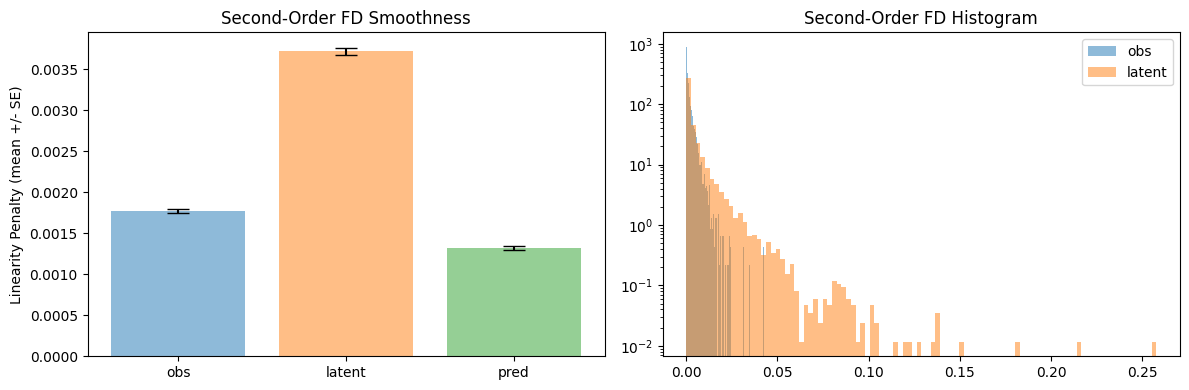

In [39]:
def second_order_fd(x):
    d_fwd = x[:, 1:, :] - x[:, :-1, :]
    dd = d_fwd[:, 1:, :] - d_fwd[:, :-1, :]
    var = x.var()
    return dd.pow(2) / var

lin_obs = second_order_fd(targets)
lin_latents = second_order_fd(latent_traj)
lin_pred = second_order_fd(decoded)

means_lin = [lin_obs.mean().item(), lin_latents.mean().item(), lin_pred.mean().item()]
std_errors_lin = [
    lin_obs.flatten().std(unbiased=True).item() / (lin_obs.numel() ** 0.5),
    lin_latents.flatten().std(unbiased=True).item() / (lin_latents.numel() ** 0.5),
    lin_pred.flatten().std(unbiased=True).item() / (lin_pred.numel() ** 0.5),
]

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].bar(labels_sm, means_lin, yerr=std_errors_lin, capsize=8, color=['C0', 'C1', 'C2'], alpha=0.5)
axs[0].set_ylabel('Linearity Penalty (mean +/- SE)'); axs[0].set_title('Second-Order FD Smoothness')
axs[1].hist(lin_obs.flatten().cpu().numpy(), bins=100, density=True, label='obs', alpha=0.5)
axs[1].hist(lin_latents.flatten().cpu().numpy(), bins=100, density=True, label='latent', alpha=0.5)
axs[1].set_yscale('log'); axs[1].set_title('Second-Order FD Histogram'); axs[1].legend()
plt.tight_layout(); plt.show()

## 16. Vector Field Consistency & Jacobian Diagnostics

### Euler Residual Consistency
$$L_{\text{consistency}} = \left\| \hat{x}_{t+1} - \left(\hat{x}_t + \hat{f}(\hat{x}_t)\,\Delta t\right) \right\|^2$$

### Jacobian Regularity (Vector Field Acceleration)
$$\| J_f(\mathbf{x})\, f(\mathbf{x}) \|^2$$

### Jacobian-Consistency (Velocity Propagation)
$$\left\| (x_{t+2} - x_{t+1}) - e^{\hat{J}\,\Delta t}(x_{t+1} - x_t) \right\|^2$$

Computing latent f:   0%|          | 0/30 [00:00<?, ?it/s]

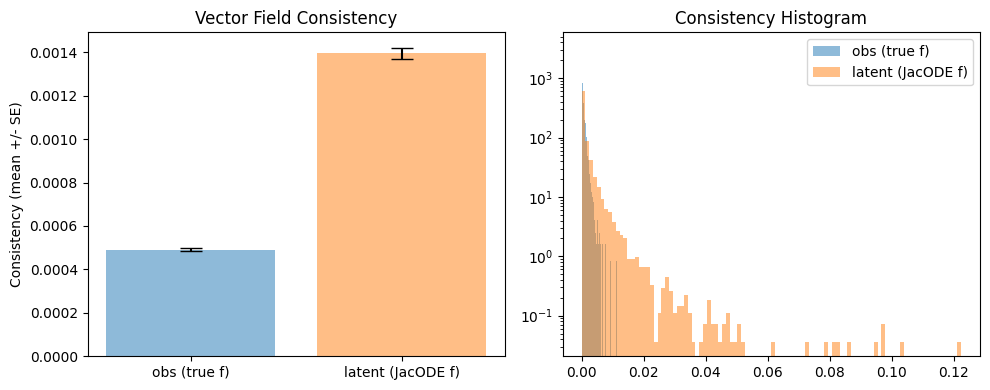

In [40]:
from JacobianODE.jacobians.jacobianODE import JacobianODE, JacobianODEint

traj_init_steps_vf = lit_model.jacobianODEint_kwargs.get('traj_init_steps', 15)

# 1. Observations: true Lorenz vector field
obs_ref_raw = (test_trajs_full * sigma + mu).numpy()
t_dummy_ref = np.zeros(obs_ref_raw.shape[1])
f_obs_raw = np.zeros_like(obs_ref_raw)
for b in range(obs_ref_raw.shape[0]):
    f_obs_raw[b] = eq.rhs(obs_ref_raw[b], t_dummy_ref)
f_obs = torch.from_numpy(f_obs_raw).float() / sigma
obs_ref = test_trajs_full
euler_resid_obs = obs_ref[:, 1:, :] - (obs_ref[:, :-1, :] + f_obs[:, :-1, :] * dt)
obs_var = obs_ref.var()
cons_obs = euler_resid_obs.pow(2) / obs_var

# 2. Latent space: JacobianODE-estimated vector field
latent_traj_dev = latent_traj.to(device)
B_vf, T_vf, D_vf = latent_traj.shape
T_pred_vf = T_vf - traj_init_steps_vf

time_vals = (torch.arange(traj_init_steps_vf) * dt).to(device).float()
z_init_all = latent_traj_dev[:, :traj_init_steps_vf, :]

jac_ode = JacobianODE(z_init_all, lit_model.compute_jacobians, time_vals)
f_func = jac_ode.get_deriv_func(
    t_0=time_vals[0], inner_path="line", fast_mode=True,
    fast_mode_base_ind=traj_init_steps_vf - 1, scale_interp_pts=True, interp_pts=4,
)

f_latent = torch.zeros(B_vf, T_pred_vf, D_vf)
for k_vf in tqdm(range(T_pred_vf), desc="Computing latent f"):
    t_k = torch.tensor((traj_init_steps_vf + k_vf) * dt, dtype=torch.float32, device=device)
    z_k = latent_traj_dev[:, traj_init_steps_vf + k_vf, :]
    f_val = f_func(t_k, z_k)
    f_latent[:, k_vf] = f_val.detach().cpu()

euler_pred_latent = latent_traj[:, traj_init_steps_vf:-1, :] + f_latent[:, :-1, :] * dt
cons_latent = (latent_traj[:, traj_init_steps_vf+1:, :] - euler_pred_latent).pow(2) / latent_traj.var()

means_cons = [cons_obs.mean().item(), cons_latent.mean().item()]
std_errors_cons = [
    cons_obs.flatten().std(unbiased=True).item() / (cons_obs.numel() ** 0.5),
    cons_latent.flatten().std(unbiased=True).item() / (cons_latent.numel() ** 0.5),
]
labels_cons = ['obs (true f)', 'latent (JacODE f)']

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].bar(labels_cons, means_cons, yerr=std_errors_cons, capsize=8, color=['C0', 'C1'], alpha=0.5)
axs[0].set_ylabel('Consistency (mean +/- SE)'); axs[0].set_title('Vector Field Consistency')
axs[1].hist(cons_obs.flatten().cpu().numpy(), bins=100, density=True, label='obs (true f)', alpha=0.5)
axs[1].hist(cons_latent.flatten().detach().cpu().numpy(), bins=100, density=True, label='latent (JacODE f)', alpha=0.5)
axs[1].set_yscale('log'); axs[1].set_title('Consistency Histogram'); axs[1].legend()
plt.tight_layout(); plt.show()

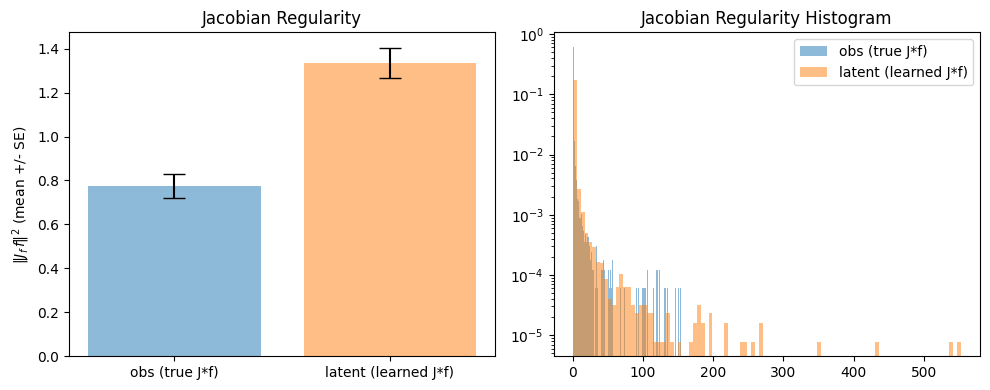

In [41]:
# Jacobian regularity: || J_f(x) f(x) ||^2
t_dummy_obs = np.zeros(obs_ref_raw.shape[1])
J_obs_raw = eq.jac(obs_ref_raw, t_dummy_obs)
Jf_obs_raw = np.einsum('btij,btj->bti', J_obs_raw, f_obs_raw)
Jf_obs_norm = torch.from_numpy(Jf_obs_raw).float() / sigma
jreg_obs = Jf_obs_norm.pow(2) / (obs_var / dt**2)

with torch.no_grad():
    jacs = lit_model.compute_jacobians(latent_traj.to(device)).cpu()
jacs_at_pred = jacs[:, traj_init_steps_vf:, :, :]
Jf_latent = torch.einsum('btij,btj->bti', jacs_at_pred, f_latent)
jreg_latent = Jf_latent.pow(2) / (latent_traj.var() / dt**2)

means_jreg = [jreg_obs.mean().item(), jreg_latent.mean().item()]
std_errors_jreg = [
    jreg_obs.flatten().std(unbiased=True).item() / (jreg_obs.numel() ** 0.5),
    jreg_latent.flatten().detach().std(unbiased=True).item() / (jreg_latent.numel() ** 0.5),
]
labels_jreg = ['obs (true J*f)', 'latent (learned J*f)']

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].bar(labels_jreg, means_jreg, yerr=std_errors_jreg, capsize=8, color=['C0', 'C1'], alpha=0.5)
axs[0].set_ylabel(r'$\|J_f\, f\|^2$ (mean +/- SE)'); axs[0].set_title('Jacobian Regularity')
axs[1].hist(jreg_obs.flatten().cpu().numpy(), bins=100, density=True, label='obs (true J*f)', alpha=0.5)
axs[1].hist(jreg_latent.flatten().detach().cpu().numpy(), bins=100, density=True, label='latent (learned J*f)', alpha=0.5)
axs[1].set_yscale('log'); axs[1].set_title('Jacobian Regularity Histogram'); axs[1].legend()
plt.tight_layout(); plt.show()

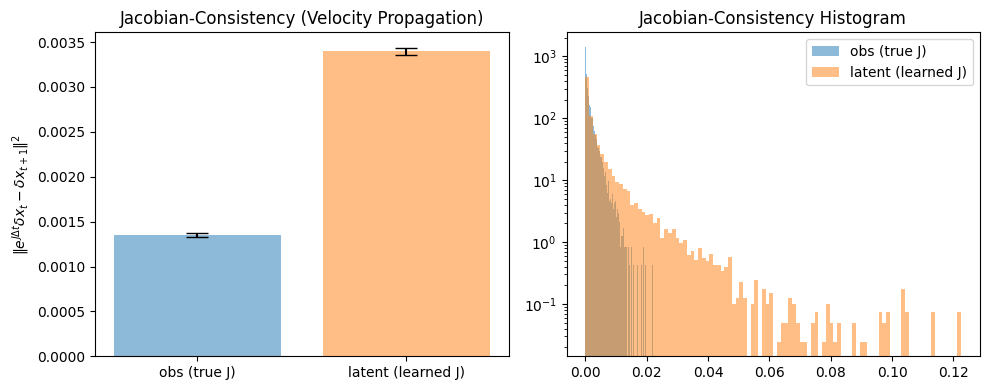

In [42]:
# Jacobian-consistency: velocity propagation via matrix exponential
J_obs_exp = torch.matrix_exp(torch.from_numpy(J_obs_raw[:, :-2]).float() * dt)
vel_obs_raw = torch.from_numpy(obs_ref_raw[:, 1:] - obs_ref_raw[:, :-1]).float()
vel_obs_t = vel_obs_raw[:, :-1]
vel_obs_t1 = vel_obs_raw[:, 1:]
vel_obs_t1_pred = (J_obs_exp @ vel_obs_t.unsqueeze(-1)).squeeze(-1)
residual_obs_norm = (vel_obs_t1 - vel_obs_t1_pred) / sigma
jac_cons_obs = residual_obs_norm.pow(2) / obs_ref.var()

J_lat_exp = torch.matrix_exp(jacs[:, :-2] * dt)
vel_lat = latent_traj[:, 1:] - latent_traj[:, :-1]
vel_lat_t = vel_lat[:, :-1]
vel_lat_t1 = vel_lat[:, 1:]
vel_lat_t1_pred = (J_lat_exp @ vel_lat_t.unsqueeze(-1)).squeeze(-1)
jac_cons_latent = (vel_lat_t1 - vel_lat_t1_pred).pow(2) / latent_traj.var()

means_jc = [jac_cons_obs.mean().item(), jac_cons_latent.mean().item()]
std_errors_jc = [
    jac_cons_obs.flatten().std(unbiased=True).item() / (jac_cons_obs.numel() ** 0.5),
    jac_cons_latent.flatten().std(unbiased=True).item() / (jac_cons_latent.numel() ** 0.5),
]
labels_jc = ['obs (true J)', 'latent (learned J)']

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].bar(labels_jc, means_jc, yerr=std_errors_jc, capsize=8, color=['C0', 'C1'], alpha=0.5)
axs[0].set_ylabel(r'$\|e^{J\Delta t}\delta x_t - \delta x_{t+1}\|^2$')
axs[0].set_title('Jacobian-Consistency (Velocity Propagation)')
axs[1].hist(jac_cons_obs.flatten().cpu().numpy(), bins=100, density=True, label='obs (true J)', alpha=0.5)
axs[1].hist(jac_cons_latent.flatten().detach().cpu().numpy(), bins=100, density=True, label='latent (learned J)', alpha=0.5)
axs[1].set_yscale('log'); axs[1].set_title('Jacobian-Consistency Histogram'); axs[1].legend()
plt.tight_layout(); plt.show()

## 17. Composite Jacobian: $J_D \, J_{\text{ODE}} \, J_E \approx J_{\text{true}}$

Verify that the autodifferentiated composition of encoder, predicted latent
Jacobian, and decoder recovers the true Lorenz Jacobian.

In [43]:
def lorenz_jacobian(x_raw, sigma_lz=10.0, rho=28.0, beta=8.0/3.0):
    x1, x2, x3 = float(x_raw[0]), float(x_raw[1]), float(x_raw[2])
    return torch.tensor([
        [-sigma_lz, sigma_lz, 0.0],
        [rho - x3, -1.0, -x1],
        [x2, x1, -beta],
    ], dtype=torch.float32)

def compute_J_E(lit_model, x_seq, t_idx):
    x_detached = x_seq.detach()
    def f(x_t):
        x_new = torch.cat([
            x_detached[:, :t_idx, :], x_t.view(1, 1, -1), x_detached[:, t_idx+1:, :],
        ], dim=1)
        z = lit_model.encoder.encode(x_new)
        return z[0, t_idx]
    return autograd_jacobian(f, x_detached[0, t_idx])

def compute_J_D(lit_model, z_t):
    def f(z):
        return lit_model.encoder.decode(z.unsqueeze(0)).squeeze(0)
    return autograd_jacobian(f, z_t)

def compute_J_ODE(lit_model, z_t):
    return lit_model.compute_jacobians(z_t.unsqueeze(0).unsqueeze(0))[0, 0]

test_seq = trajs['test_trajs'].sequence[:1].to(device)
test_seq_full = test_trajs_full[:1].to(device)
T_test = test_seq.shape[1]

sigma_device = torch.as_tensor(sigma, dtype=torch.float32, device=device)
mu_device = torch.as_tensor(mu, dtype=torch.float32, device=device)

STEP = 2; T_START = 5
t_indices = range(T_START, T_test - 1, STEP)

J_composites = []
J_trues = []

with torch.no_grad():
    z_seq = lit_model.encode_trajectory(test_seq)

for t_idx in tqdm(t_indices, desc="Composite Jacobians"):
    z_t = z_seq[0, t_idx].detach()
    x_t_n = test_seq_full[0, t_idx].detach()
    with torch.no_grad():
        J_ode = compute_J_ODE(lit_model, z_t)
    with torch.enable_grad():
        J_d = compute_J_D(lit_model, z_t)
        J_e = compute_J_E(lit_model, test_seq, t_idx)
    J_comp = J_d @ J_ode @ J_e
    x_raw = x_t_n * sigma_device + mu_device
    J_true = lorenz_jacobian(x_raw)
    J_composites.append(J_comp.detach().cpu())
    J_trues.append(J_true.cpu())

J_composites = torch.stack(J_composites)
J_trues = torch.stack(J_trues)

frob_errors = torch.norm(J_composites - J_trues, dim=(-2, -1))
frob_true = torch.norm(J_trues, dim=(-2, -1))
rel_errors = frob_errors / (frob_true + 1e-8)

comp_flat = J_composites.reshape(-1).numpy()
true_flat = J_trues.reshape(-1).numpy()
corr = float(np.corrcoef(comp_flat, true_flat)[0, 1])
r2_val = r2_score(true_flat, comp_flat)

print("Composite Jacobian test results")
print("=" * 38)
print(f"Frobenius error  -- mean: {frob_errors.mean():.4f}  |  std: {frob_errors.std():.4f}")
print(f"Relative error   -- mean: {rel_errors.mean():.4f}  |  std: {rel_errors.std():.4f}")
print(f"Entry correlation:       {corr:.4f}")
print(f"R^2:                     {r2_val:.4f}")

Composite Jacobians:   0%|          | 0/597 [00:00<?, ?it/s]

Composite Jacobian test results
Frobenius error  -- mean: 10.2436  |  std: 4.4745
Relative error   -- mean: 0.4702  |  std: 0.1286
Entry correlation:       0.8566
R^2:                     0.7312


## 18. False Nearest Neighbors (FNN) Loss

FNN loss -- True state:   0.683679
FNN loss -- Latent:       0.691290


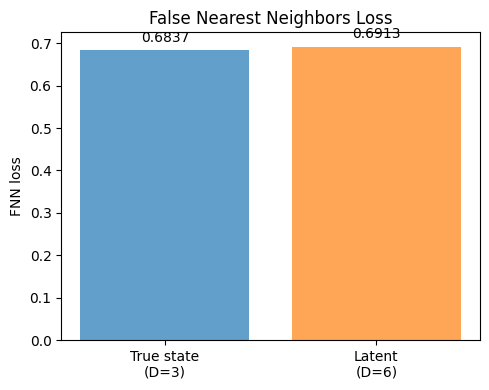

In [44]:
rng_fnn = np.random.default_rng(42)
X_true_fnn = test_trajs_full.reshape(-1, test_trajs_full.shape[-1]).float()
X_latent_fnn = latent_traj_full.reshape(-1, latent_traj_full.shape[-1]).float()
N_POINTS = len(X_true_fnn)
idx_true = rng_fnn.choice(len(X_true_fnn), N_POINTS, replace=False)
idx_latent = rng_fnn.choice(len(X_latent_fnn), N_POINTS, replace=False)
X_true_sub = X_true_fnn[torch.from_numpy(idx_true)]
X_latent_sub = X_latent_fnn[torch.from_numpy(idx_latent)]

with torch.no_grad():
    fnn_loss_true = loss_false(X_true_sub, k=2, normalize=True).item()
    fnn_loss_latent = loss_false(X_latent_sub, k=2, normalize=True).item()

print(f"FNN loss -- True state:   {fnn_loss_true:.6f}")
print(f"FNN loss -- Latent:       {fnn_loss_latent:.6f}")

D_latent_fnn = X_latent_fnn.shape[-1]
labels_fnn = [f'True state\n(D={X_true_fnn.shape[-1]})', f'Latent\n(D={D_latent_fnn})']
values_fnn = [fnn_loss_true, fnn_loss_latent]
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels_fnn, values_fnn, color=['C0', 'C1'], alpha=0.7)
ax.set_ylabel('FNN loss'); ax.set_title('False Nearest Neighbors Loss')
for bar, val in zip(bars, values_fnn):
    ax.annotate(f'{val:.4f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', va='bottom')
plt.tight_layout(); plt.show()

In [45]:
# fnn_losses_true = []
# fnn_losses_latent = []
# for k_fnn in range(1, 20):
#     fnn_losses_true.append(loss_false(X_true_sub, k=k_fnn, normalize=True).item())
#     fnn_losses_latent.append(loss_false(X_latent_sub, k=k_fnn, normalize=True).item())

# fig, ax = plt.subplots(figsize=(5, 4))
# plt.plot(range(1, 20), fnn_losses_true, label='True state')
# plt.plot(range(1, 20), fnn_losses_latent, label='Latent')
# plt.yscale('log'); plt.xlabel('k (neighbors)'); plt.ylabel('FNN loss')
# plt.legend(); plt.title('FNN Loss vs k')
# plt.show()

## 19. Amplification Loss

Amplification loss -- True state: 0.000311
Amplification loss -- Latent:     0.000316


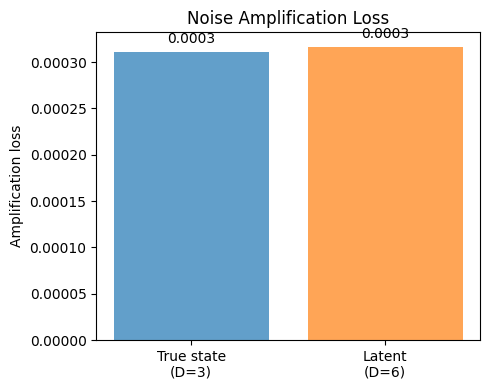

In [46]:
N_TRAJS_AMP = 64
N_NEIGHBORS = 2
MAX_T = 5
rng_amp = np.random.default_rng(42)
B_amp = test_trajs_full.shape[0]
idx_amp = rng_amp.choice(B_amp, min(N_TRAJS_AMP, B_amp), replace=False)
X_true_ts = test_trajs_full[torch.from_numpy(idx_amp)].float()
X_latent_ts = latent_traj_full[torch.from_numpy(idx_amp)].float()

with torch.no_grad():
    amp_loss_true = loss_amplification(X_true_ts, X_true_ts, n_neighbors=N_NEIGHBORS, max_T=MAX_T, normalize=True).item()
    amp_loss_latent = loss_amplification(X_latent_ts, X_true_ts, n_neighbors=N_NEIGHBORS, max_T=MAX_T, normalize=True).item()

print(f"Amplification loss -- True state: {amp_loss_true:.6f}")
print(f"Amplification loss -- Latent:     {amp_loss_latent:.6f}")

labels_amp = [f'True state\n(D={X_true_ts.shape[-1]})', f'Latent\n(D={X_latent_ts.shape[-1]})']
values_amp = [amp_loss_true, amp_loss_latent]
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels_amp, values_amp, color=['C0', 'C1'], alpha=0.7)
ax.set_ylabel('Amplification loss'); ax.set_title('Noise Amplification Loss')
for bar, val in zip(bars, values_amp):
    ax.annotate(f'{val:.4f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', va='bottom')
plt.tight_layout(); plt.show()

In [47]:
# N_NEIGHBORS_VALS = np.arange(2, 21)
# MAX_T_VALS = np.arange(2, 21)
# heatmap_diff = np.zeros((len(MAX_T_VALS), len(N_NEIGHBORS_VALS)))

# with torch.no_grad():
#     for i, max_t in enumerate(MAX_T_VALS):
#         for j, n_nbrs in enumerate(N_NEIGHBORS_VALS):
#             amp_true = loss_amplification(
#                 X_true_ts, X_true_ts, n_neighbors=int(n_nbrs), max_T=int(max_t), normalize=True
#             ).item()
#             amp_latent = loss_amplification(
#                 X_latent_ts, X_true_ts, n_neighbors=int(n_nbrs), max_T=int(max_t), normalize=True
#             ).item()
#             heatmap_diff[i, j] = amp_latent - amp_true

# fig, ax = plt.subplots(figsize=(8, 6))
# abs_max = np.abs(heatmap_diff).max()
# im = ax.imshow(heatmap_diff, aspect='auto', origin='lower',
#     extent=[N_NEIGHBORS_VALS[0], N_NEIGHBORS_VALS[-1], MAX_T_VALS[0], MAX_T_VALS[-1]],
#     cmap='RdBu_r', vmin=-abs_max, vmax=abs_max)
# cbar = plt.colorbar(im, ax=ax)
# cbar.set_label("Amplification loss\nLatent " + r"- True ($\Delta \sigma$)", fontsize=12)
# ax.set_xlabel(r"Number of neighbors ($K$)", fontsize=12)
# ax.set_ylabel(r"Max lookahead ($T$ steps)", fontsize=12)
# ax.set_title("Amplification Loss Difference\n(latent minus true state)", fontsize=14)
# plt.tight_layout(); plt.show()

## 20. Observation-Space Jacobian via Chain Rule

When `n_delays == 1` (no delay embedding), the observation **is** the true state.
We map the model's predicted latent Jacobian back to observation space via:

$$J_{\text{obs}}^{\text{pred}} \approx \frac{\partial D}{\partial z}\bigg|_{z_t} \; J_{\text{latent}}^{\text{pred}}(z_t) \; \frac{\partial E}{\partial x}\bigg|_{x_t}$$

Trajectories:   0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipykernel_3395548/1122485202.py:26: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x_raw_j = np.array(trajs['test_trajs'].sequence[traj_i]) * sigma_arr + mu_arr


  Traj 0:   0%|          | 0/100 [00:00<?, ?it/s]

  Traj 1:   0%|          | 0/100 [00:00<?, ?it/s]

  Traj 2:   0%|          | 0/100 [00:00<?, ?it/s]


Obs-space Jacobian comparison (300 samples)
Overall R^2: 0.7470


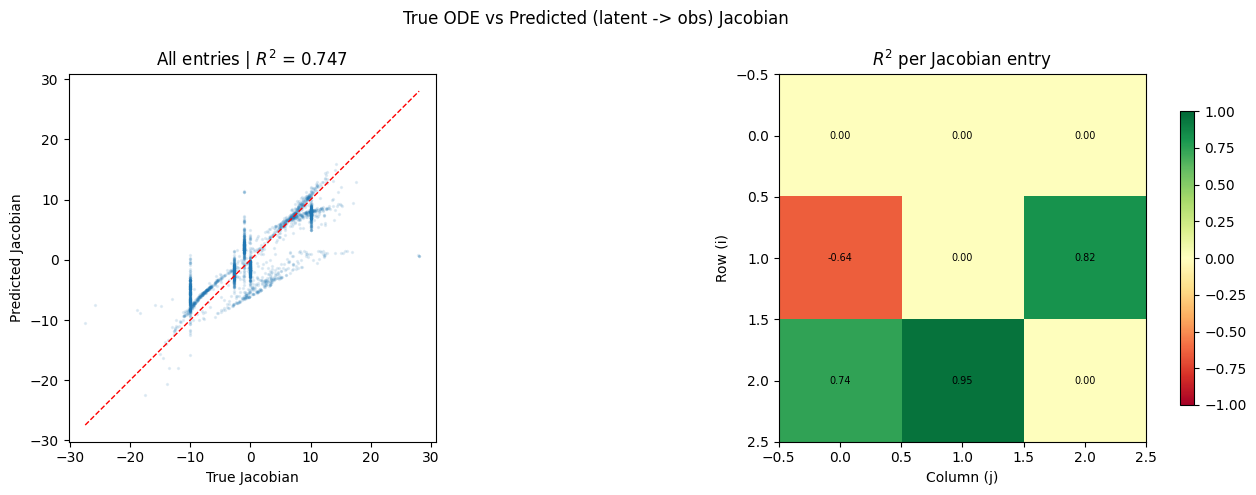

In [48]:
n_delays_cfg = best_cfg.data.train_test_params.delay_embedding_params.n_delays

if n_delays_cfg != 1:
    print(f"Skipping chain-rule Jacobian comparison: n_delays={n_delays_cfg} (need 1)")
else:
    mu_arr = np.atleast_1d(np.array(mu))
    sigma_arr = np.atleast_1d(np.array(sigma))

    N_TRAJS_JAC = min(3, trajs['test_trajs'].sequence.shape[0])
    N_SAMPLE_PTS = 100
    margin = getattr(lit_model.encoder, 'context_margin', 0)

    all_J_true = []
    all_J_pred = []

    for traj_i in tqdm(range(N_TRAJS_JAC), desc="Trajectories"):
        x_norm_t = torch.as_tensor(
            trajs['test_trajs'].sequence[traj_i:traj_i+1]
        ).float().to(device)
        with torch.no_grad():
            z_full_j = lit_model.encode_trajectory(x_norm_t)
            J_pred_full = lit_model.compute_jacobians(z_full_j)
        T_prime = z_full_j.shape[1]
        n_latent_j = z_full_j.shape[2]
        n_obs_j = x_norm_t.shape[2]
        x_raw_j = np.array(trajs['test_trajs'].sequence[traj_i]) * sigma_arr + mu_arr
        sample_idx = np.sort(np.random.choice(T_prime, min(N_SAMPLE_PTS, T_prime), replace=False))

        for t_z in tqdm(sample_idx, desc=f"  Traj {traj_i}", leave=False):
            t_x = t_z + margin
            J_raw = eq.jac(x_raw_j[t_x:t_x+1], t=0)[0]
            J_raw_t = torch.tensor(J_raw, dtype=torch.float32, device=device)
            sigma_t = torch.tensor(sigma_arr, dtype=torch.float32, device=device)
            J_norm = J_raw_t if sigma_t.numel() == 1 else (1.0/sigma_t).unsqueeze(1) * J_raw_t * sigma_t.unsqueeze(0)

            x_inp = x_norm_t.detach().clone().requires_grad_(True)
            z_out = lit_model.encode_trajectory(x_inp)
            J_enc = torch.zeros(n_latent_j, n_obs_j, device=device)
            for j in range(n_latent_j):
                retain = (j < n_latent_j - 1)
                g = torch.autograd.grad(z_out[0, t_z, j], x_inp, retain_graph=retain)[0]
                J_enc[j] = g[0, t_x]

            z_pt = z_full_j[0, t_z].detach().clone().requires_grad_(True)
            x_hat = lit_model.encoder.decode(z_pt.unsqueeze(0)).squeeze(0)
            J_dec = torch.zeros(n_obs_j, n_latent_j, device=device)
            for k_j in range(n_obs_j):
                retain = (k_j < n_obs_j - 1)
                g = torch.autograd.grad(x_hat[k_j], z_pt, retain_graph=retain)[0]
                J_dec[k_j] = g

            J_pred_latent = J_pred_full[0, t_z]
            J_obs_pred = J_dec @ J_pred_latent @ J_enc
            all_J_true.append(J_norm.detach().cpu())
            all_J_pred.append(J_obs_pred.detach().cpu())

    all_J_true = torch.stack(all_J_true)
    all_J_pred = torch.stack(all_J_pred)

    Jt_flat = all_J_true.reshape(-1).numpy()
    Jp_flat = all_J_pred.reshape(-1).numpy()
    r2_overall = r2_score(Jt_flat, Jp_flat)

    d = all_J_true.shape[1]
    r2_matrix = np.zeros((d, d))
    for i in range(d):
        for j in range(d):
            y = all_J_true[:, i, j].numpy()
            yhat = all_J_pred[:, i, j].numpy()
            ss_t = np.sum((y - y.mean())**2)
            r2_matrix[i, j] = 1 - np.sum((y - yhat)**2) / ss_t if ss_t > 1e-12 else 0.0

    print(f"\nObs-space Jacobian comparison ({len(all_J_true)} samples)")
    print(f"Overall R^2: {r2_overall:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    ax.scatter(Jt_flat, Jp_flat, alpha=0.1, s=2)
    lims = [min(Jt_flat.min(), Jp_flat.min()), max(Jt_flat.max(), Jp_flat.max())]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel("True Jacobian"); ax.set_ylabel("Predicted Jacobian")
    ax.set_title(f"All entries | $R^2$ = {r2_overall:.3f}"); ax.set_aspect('equal')

    ax = axes[1]
    im = ax.imshow(r2_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(d):
        for j in range(d):
            ax.text(j, i, f"{r2_matrix[i, j]:.2f}", ha='center', va='center', fontsize=7)
    ax.set_xlabel("Column (j)"); ax.set_ylabel("Row (i)")
    ax.set_title("$R^2$ per Jacobian entry")
    plt.suptitle("True ODE vs Predicted (latent -> obs) Jacobian")
    plt.tight_layout(); plt.show()

## 21. Export HTML

In [49]:
import subprocess
from datetime import datetime

now_str = datetime.now().strftime("%Y-%m-%d %H-%M-%S")
output_file = f"reports/{now_str} - {WANDB_PROJECT}_{WANDB_GROUP}_lambda_{best_lambda}"
cmd = f"uv run jupyter nbconvert --to html --output '{output_file}' '/home/eisenaj/code/JacobianODE/_jupyter/Sweep Analytics (Latent JacobianODE).ipynb'"
# Uncomment to export:
subprocess.run(cmd, shell=True)
# print(f"Export command:\n{cmd}")

[NbConvertApp] Converting notebook /home/eisenaj/code/JacobianODE/_jupyter/Sweep Analytics (Latent JacobianODE).ipynb to html
/orcd/home/002/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
[NbConvertApp] WARNING | Alternative text is missing on 22 image(s).
[NbConvertApp] Writing 2776544 bytes to /home/eisenaj/code/JacobianODE/_jupyter/reports/2026-03-13 10-45-28 - Lorenz_IND012_N1_D1_NormTrue_L6__JacobianODE_sweep_from_scratch_lc_only_fnn1e-5_enc_warmup_5_lambda_1e-05.html


CompletedProcess(args="uv run jupyter nbconvert --to html --output 'reports/2026-03-13 10-45-28 - Lorenz_IND012_N1_D1_NormTrue_L6__JacobianODE_sweep_from_scratch_lc_only_fnn1e-5_enc_warmup_5_lambda_1e-05' '/home/eisenaj/code/JacobianODE/_jupyter/Sweep Analytics (Latent JacobianODE).ipynb'", returncode=0)